## Example on SSO sheets

#### This Juptyer Notebook is just an example of using MeteoSaver on UK SSO sheets

For detailed explanations of each of the configuration settings see **MeteoSaver v1.0 User Manual, Section 3** and **Muheki et al. 2025**

### Step 1: Set Up the Python Environment

⚠️ Ensure this notebook is located in your user path, where the ipython  is e.g. in C:\Users\dmuheki\

In [2]:
import os, subprocess, sys, pathlib
from pathlib import Path

venv_dir = Path.cwd() / "meteosaver_virtual_environment"

# 1) Create the venv if it doesn't exist
if not venv_dir.exists():
    subprocess.check_call([sys.executable, "-m", "venv", str(venv_dir)])

# 2) Resolve the venv's python
venv_py = venv_dir / ("Scripts" if os.name == "nt" else "bin") / ("python.exe" if os.name == "nt" else "python")
assert venv_py.exists(), f"Venv python not found: {venv_py}"

# 3) Ensure pip + ipykernel are in the venv
subprocess.check_call([str(venv_py), "-m", "pip", "install", "--upgrade", "pip", "ipykernel"])

# 4) Register a Jupyter kernel for this venv (unique name helps avoid collisions)
kernel_name = "meteosaver_venv_local"
display_name = "MeteoSaver venv (local)"
subprocess.check_call([str(venv_py), "-m", "ipykernel", "install", "--user",
                       "--name", kernel_name, "--display-name", display_name])

print("Venv ready at:", venv_dir)
print("Kernel installed as:", display_name)

Venv ready at: C:\Users\dmuheki\meteosaver_virtual_environment
Kernel installed as: MeteoSaver venv (local)


#### ⚠️ Restart your Jupyter Notebook, such that this new virtual environment is detected

To do this, select **Kernel** on the Menu Tab, then **Shut Down**. The Select **File** followed by **Close and Halt**. Lastly, **Quit** the Jupyter Server, and Launch it again.

You can then re-open your notebook and chose **Kernel** -> **Change Kernel** -> **MeteoSaver venv (local)**.¶

### Continue from here after restarting

⚠️ This might take sometime to install all the required packages

In [3]:
# Check if you already git-cloned MeteoSaver. If so, use the existing requirements.in file to setup the virtual (python) environment 
import os, subprocess, sys, pathlib
from pathlib import Path
if os.path.exists('MeteoSaver'):
    print('MeteoSaver already cloned')
    print('Retrieving the requirements.in file in order to etup the virtual (python) environment')
    %cd MeteoSaver
    print("Exists requirements.in:", pathlib.Path("requirements.in").is_file())
    print("\n--- requirements.in ---")
    print(pathlib.Path("requirements.in").read_text())
    
    # Install all the required packages in the virtual (python) environment
    p = subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.in", "-v"], text=True, capture_output=True)
    print(p.stdout)
    print("\n---  STDERR ---\n", p.stderr)
    print("---DONE---")
    
else:
    # clone the MeteoSaver repository to your computer
    !git clone -b version-1.1_including_precip_and_dry_and_wet_bulb_temp https://github.com/VUB-HYDR/MeteoSaver.git
    %cd MeteoSaver
    print("Exists requirements.in:", pathlib.Path("requirements.in").is_file())
    print("\n--- requirements.in ---")
    print(pathlib.Path("requirements.in").read_text())
    
    # Install all the required packages in the virtual (python) environment
    p = subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.in", "-v"], text=True, capture_output=True)
    print(p.stdout)
    print("---DONE---")


MeteoSaver already cloned
Retrieving the requirements.in file in order to etup the virtual (python) environment
/home/test01/MeteoSaver
Exists requirements.in: True

--- requirements.in ---
opencv-python~=4.6.0.66
numpy~=1.26.4
matplotlib
scikit-learn~=1.4.1.post1
openpyxl~=3.1.2
pytesseract~=0.3.13
easyocr~=1.7.2
pandas~=2.0.3
pytesseract~=0.3.13
scipy~=1.11.4
pillow~=9.4.0
paddleocr~=2.6.1.3
cartopy~=0.22.0


/home/marekjacob/venv39/lib64/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


Using pip 21.3.1 from /home/marekjacob/venv39/lib64/python3.9/site-packages/pip (python 3.9)


---  STDERR ---
You should consider upgrading via the '/home/marekjacob/venv39/bin/python3 -m pip install --upgrade pip' command.

---DONE---


### Step 2: Loading an test image 

In [4]:
# Input path for an image of your choice

image_path = "data/00_post1960_DRC_hydroclimate_datasheet_images/001/001_1910_01_SF.jpg"  # Replace this with an image of your choice


##### How the Image Pre-processing works

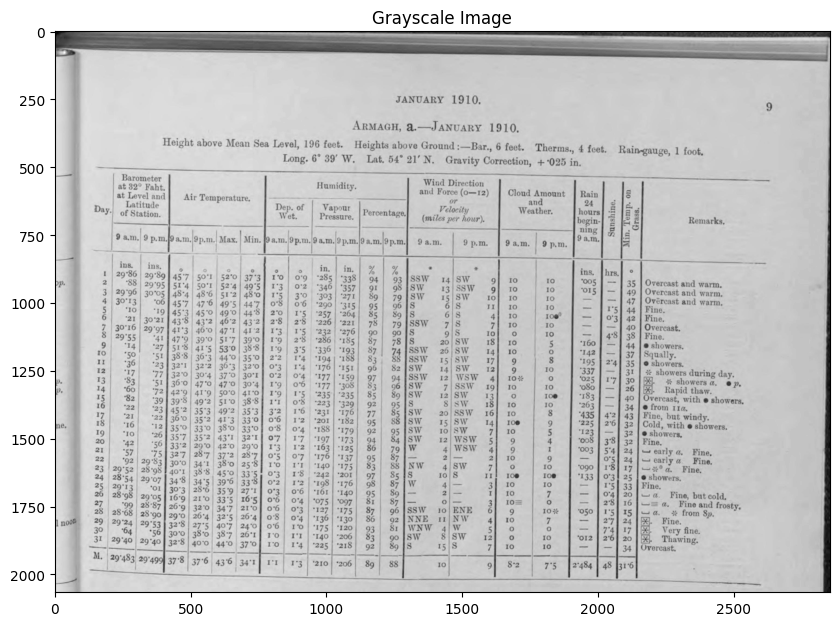

In [5]:
import cv2
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 10]
%matplotlib inline

## Read Image from the given image path
original_image  = cv2.imread(image_path)
# Convert image to grayscale
image_in_grayscale = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_in_grayscale, cmap='gray')
plt.title('Grayscale Image')
plt.show()

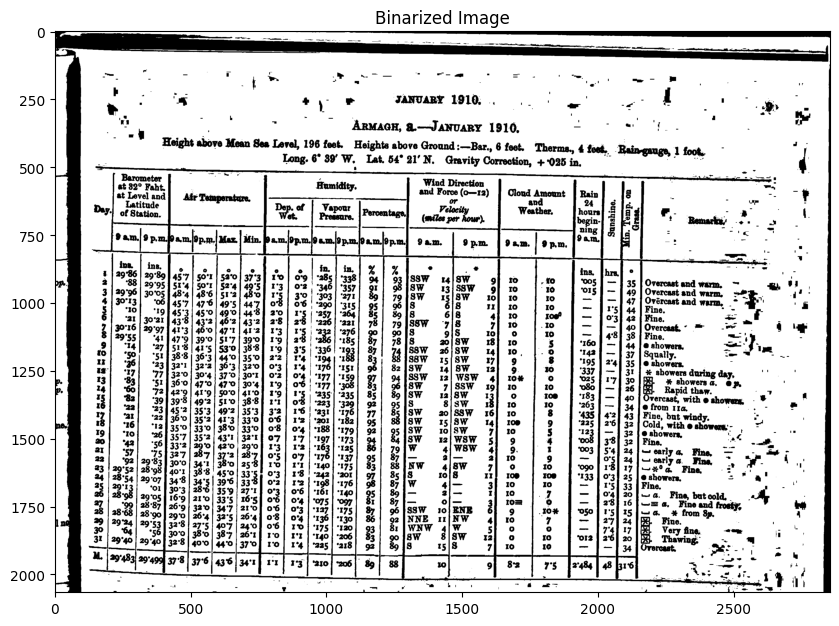

In [6]:
# Apply adaptive thresholding to the grayscale image (to reduce the image to black or white pixels)
#  The method calculates the threshold for small regions (here: 151x151 block size) 
# of the image using the mean of pixel intensities within that region. The threshold is then adjusted by subtracting a constant (here: 6). 
# Pixels above the threshold are set to 255 (white), and those below are set to 0 (black).
# You can change these constants/parameters incase these initial settings do not worfk for your use case:
binarized_image = cv2.adaptiveThreshold(image_in_grayscale, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 141, 2)

# Plotting the binarized images
plt.imshow(binarized_image, cmap='gray')
plt.title('Binarized Image')
plt.savefig("results/05_transient_transcription_output/001/tenyearrainfallsheetbinarized", dpi=300)
plt.show()


### Step 3: Testing Configuration Settings for Table and Cell Detection

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 10]
%matplotlib inline
from sklearn.cluster import KMeans





[DEBUG] Detected skew angle: 0.95 degrees (Page Rotated) ...


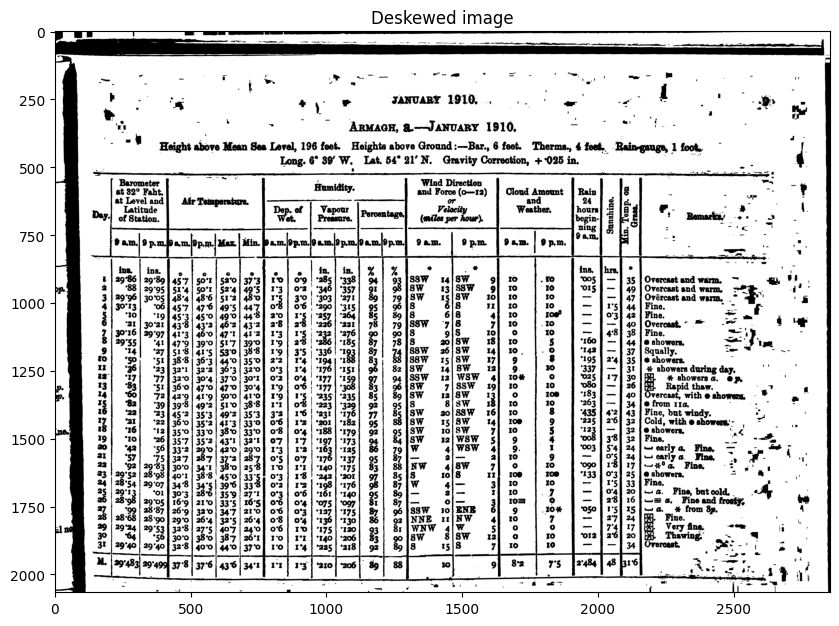

In [8]:
def detect_lines(image, kernel_size, iterations):
    '''
    Detects lines in an image using morphological operations and returns the contours of the detected lines.

    This function processes an input image to detect lines by applying binary thresholding followed by a series of morphological operations (erosion and dilation). It first converts the image to grayscale if necessary, then uses a rectangular structuring element to enhance line structures in the image. The resulting lines are detected by finding contours on the processed image.

    Parameters
    --------------
    image : 
        The input image in which lines are to be detected. The image can be in grayscale or BGR format; if in BGR format, it will be converted to grayscale.
    
    kernel_size : tuple of int
        The size of the structuring element used for the morphological operations. This tuple determines the dimensions of the rectangular kernel (width, height) that will be used for erosion and dilation.
    
    iterations : int
        The number of times the morphological operations (erosion and dilation) will be applied. Increasing the number of iterations can help to connect broken lines or separate closely spaced lines.

    Returns
    --------------
    contours : list of numpy.ndarray
        A list of contours representing the detected lines in the image. Each contour is an array of points that outline a detected line.
    '''


    # Convert to grayscale if necessary
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Use binary thresholding
    _, img_bin = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Define a kernel for morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)

    # Detect lines using morphological operations
    eroded_image = cv2.erode(img_bin, kernel, iterations=iterations)
    lines = cv2.dilate(eroded_image, kernel, iterations=iterations)

    # Find contours of the lines
    contours, _ = cv2.findContours(lines, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    return contours



def calculate_average_angle(contours, orientation='horizontal'):
    '''
    Calculates the average angle of contours relative to the specified orientation (horizontal or vertical).

    This function computes the angles of a set of contours based on their bounding rectangles. Depending on the specified orientation, it calculates the angle between the width and height of each contour's bounding box. The function then returns the average angle of all contours, which can provide insight into the overall alignment or skewness of the detected shapes.

    Parameters
    --------------
    contours : list
        A list of contours, where each contour is an array of points representing a detected shape in the image.
    
    orientation : str, optional
        The reference orientation for calculating angles. Accepts 'horizontal' or 'vertical'.
        - 'horizontal': The angle is calculated relative to the horizontal axis (based on width and height).
        - 'vertical': The angle is calculated relative to the vertical axis (based on height and width).
        The default value is 'horizontal'.

    Returns
    --------------
    average_angle : float
        The average angle of the contours relative to the specified orientation, measured in degrees.
        If no valid angles are found, the function returns 0.
    '''

    angles = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if orientation == 'horizontal' and w > 0:  # Avoid division by zero
            angle = np.degrees(np.arctan2(h, w))
        elif orientation == 'vertical' and h > 0:  # Avoid division by zero
            angle = np.degrees(np.arctan2(w, h))
        else:
            continue
        angles.append(angle)

    if angles:
        average_angle = np.mean(angles)
    else:
        average_angle = 0

    return average_angle


def deskew(image):
    '''
    Rotates the entire image (page) while keeping text naturally aligned.

    This function detects the skew angle of horizontal lines and rotates the page accordingly.
    The text remains visually undistorted because it rotates with the page, maintaining correct orientation.

    Parameters
    --------------
    image : 
        The input image that needs to be deskewed.

    Returns
    --------------
    deskewed_image : 
        The deskewed image after rotation.
    '''

    # Detect horizontal lines and calculate the average skew angle
    hor_contours = detect_lines(image, (np.array(image).shape[1] // 20, 1), iterations=1)
    hor_angle = calculate_average_angle(hor_contours, orientation='horizontal')

    # If the detected angle is too small, no need to rotate
    if abs(hor_angle) < 0.1:
        print("[DEBUG] No significant skew detected. Returning original image ...")
        return image

    # Get image dimensions
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)  # Compute the center of rotation

    # Compute rotation matrix
    M = cv2.getRotationMatrix2D(center, hor_angle, 1.0)  # Rotate page to align it

    # Rotate the image using affine transformation
    deskewed_image = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)

    print(f"[DEBUG] Detected skew angle: {hor_angle:.2f} degrees (Page Rotated) ...")

    return deskewed_image, hor_angle


binarized_image, skew_angle = deskew(binarized_image)
plt.imshow(binarized_image, cmap='gray')
plt.title("Deskewed image")
plt.show()


#### 3.1 Setting: max_table_width and max_table_height 

By viewing the binarized image displayed above, you can already estimate the maximum table width and maximum table height in Pixels (See the x and y axis grid labels). Here, we estimate max_table_width = 3900 and max_table_height = 3600. We can then check these estimates in the following steps, where by we detect the table (the largest contour) from the image.

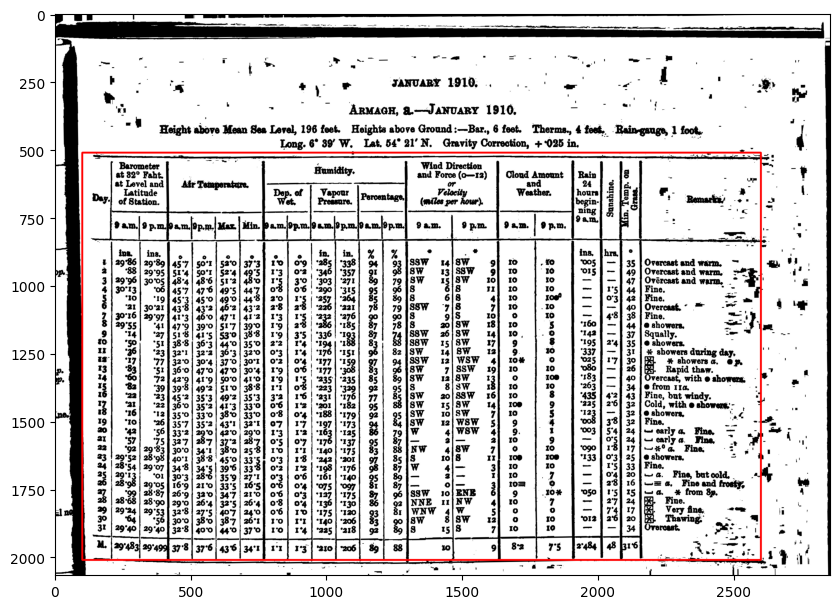

In [9]:
max_table_width = 2500 # trial, update this according to your binary image grid
max_table_height =1500 # trial, update this according to your binary image grid

# Imaginary grid starting top x and y (0,0) table coordinates. We will use these to overlay an imaginary table over the binary image
x = 100   # trial, update this according to your binary image grid
y = 510    # trial, update this according to your binary image grid

binarized_image_in_RGB = cv2.cvtColor(binarized_image, cv2.COLOR_GRAY2RGB)
cv2.rectangle(binarized_image_in_RGB, (x, y), (x + max_table_width, y + max_table_height), (255, 0, 0), 5)
plt.imshow(binarized_image_in_RGB)
plt.show()

## NOTE: This isnt the automatic Table and Cell Detection yet. 
#        This step is only to determine estimates of max_table_width and max_table_height for the configuration module
#        After, you confirm the estimates of max_table_width and max_table_height using the plot below (matching your table),
#        set these max_table_width and max_table_height values in the configuration.ini in your MeteoSaver directory.

#### 3.2 Setting: clip_up, clip_down, clip_left, clip_right 

Similar to determining estimates of max_table_width and max_table_height above, we also estimate values for clip_up, clip_down, clip_left, and clip_right in order to remove headers and row labels from the automatically detected tables.

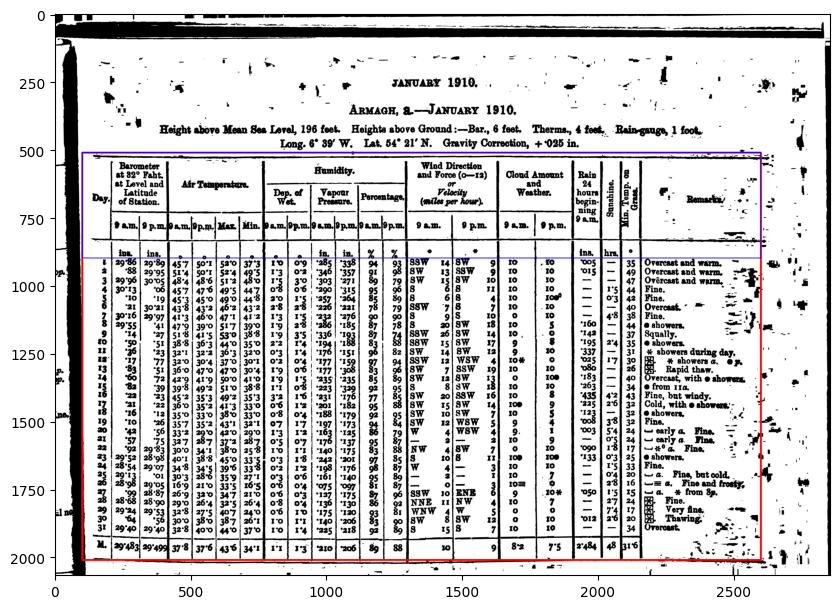

In [10]:
# still using the values table origin (x,y) coordinates from above,
# we estimate the width and height of the headers, 
# using trial and error until we have an estimate of the clip of headers and row labels -> clip_up, clip_down, clip_left, clip_right values

clip_up = 388    # trial, update this according to your binary image grid
# If you do not want to clip table, set this value to zero (0)

binarized_image_in_RGB_copy_clipped_header = binarized_image_in_RGB.copy()
cv2.rectangle(binarized_image_in_RGB_copy_clipped_header, (x, y), (x + max_table_width, y + clip_up), (0, 0, 255), 2)
plt.imshow(binarized_image_in_RGB_copy_clipped_header)
plt.show()

# Clipped header shown in blue. If it matches,aftr trial and error, the update the clip_up value in the configuration.ini in the MeteoSaver directory 

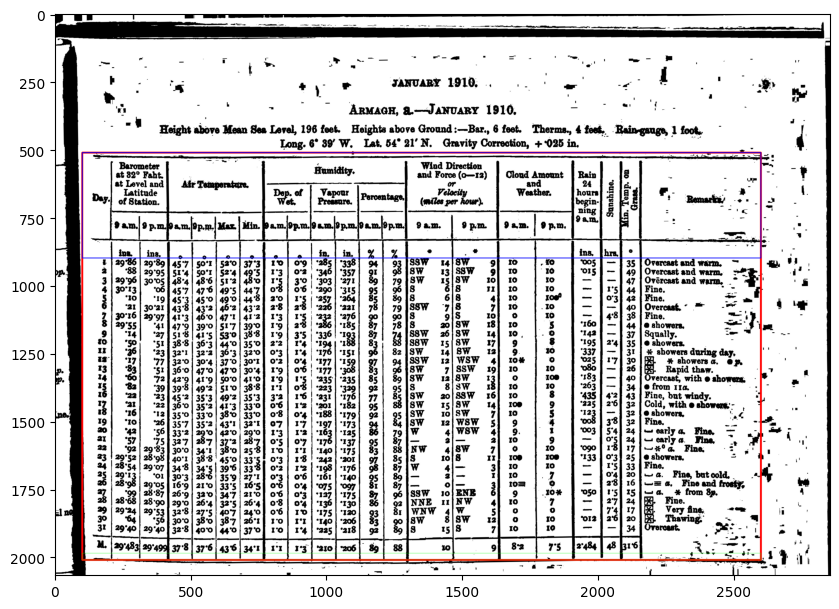

In [11]:
clip_down = 25    # trial, update this according to your binary image grid
# If you do not want to clip table, set this value to zero (0)

binarized_image_in_RGB_copy_clipped_lower_table = binarized_image_in_RGB_copy_clipped_header.copy()
cv2.rectangle(binarized_image_in_RGB_copy_clipped_lower_table, (x, y + max_table_height), (x + max_table_width, y + max_table_height - clip_down), (0, 255, 0), 1)
plt.imshow(binarized_image_in_RGB_copy_clipped_lower_table)

plt.show()

# Clipped bottom of the table shown in green. If it matches what you want to clip, after trial and error, the update the clip_down value in the configuration.ini in the MeteoSaver directory

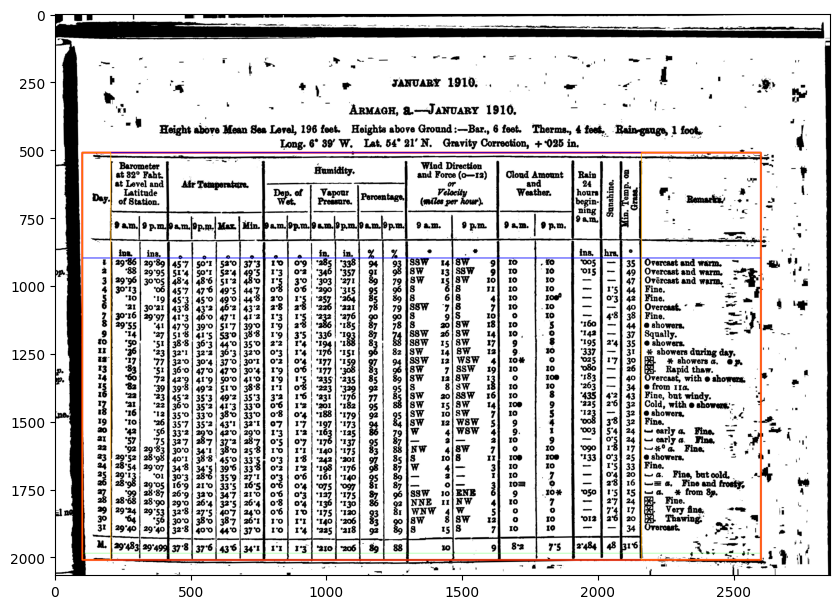

In [12]:
clip_left = 105    # trial, update this according to your binary image grid
clip_right = 440   # trial, update this according to your binary image grid
# If you do not want to clip table, set these values to zero (0)

binarized_image_in_RGB_copy_clipped_row_labels = binarized_image_in_RGB_copy_clipped_lower_table.copy()
cv2.rectangle(binarized_image_in_RGB_copy_clipped_row_labels, (x, y), (x + clip_left, y + max_table_height), (255, 165, 0), 2)
cv2.rectangle(binarized_image_in_RGB_copy_clipped_row_labels, (x + max_table_width - clip_right, y), (x + max_table_width, y + max_table_height), (255, 165, 0), 2)
plt.imshow(binarized_image_in_RGB_copy_clipped_row_labels)
plt.savefig("results/05_transient_transcription_output/001/transcribed_table_dimensions", dpi=300)
plt.show()

# Clipped sides (row labels) of the table shown in orange. If it matches what you want to clip, after trial and error, the update the clip_left and/or clip_right values in the configuration.ini in the Me

#### 3.3 Setting: min_cell_width_threshold, max_cell_width_threshold, min_cell_height_threshold, max_cell_height_threshold

Similar to the trials to determine estimate values above, we also determine estimates for the average cell dimensions, i.e., min_cell_width_threshold, max_cell_width_threshold, min_cell_height_threshold, max_cell_height_threshold

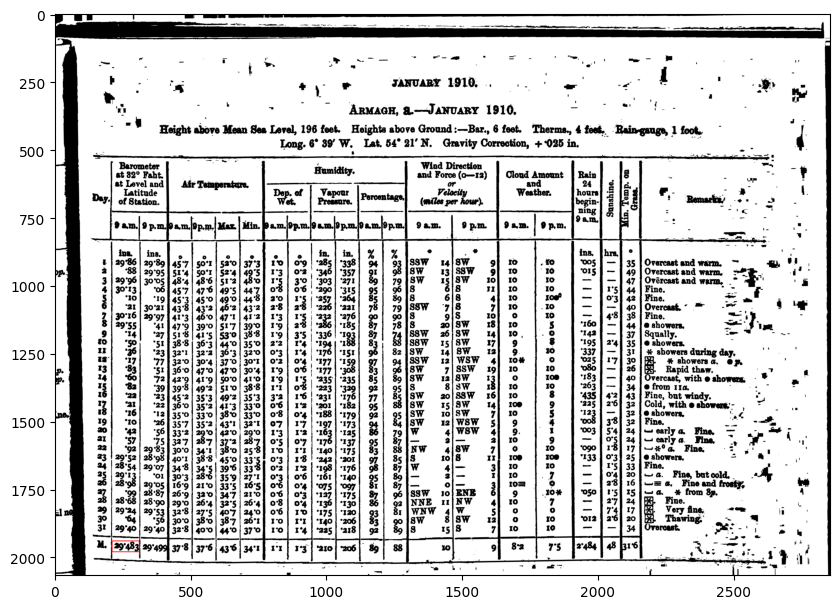

In [13]:
# Here we plot two cells: one representing the minimum cell dimensions and the other the maximum cell dimensions

# Pick a random point in the table
x_max_random = 210
y_max_random = 1940

max_cell_width_threshold = 100
max_cell_height_threshold = 40

binarized_image_in_RGB_max_cell = cv2.cvtColor(binarized_image, cv2.COLOR_GRAY2RGB)
cv2.rectangle(binarized_image_in_RGB_max_cell, (x_max_random, y_max_random), (x_max_random + max_cell_width_threshold, y_max_random + max_cell_height_threshold), (255, 0, 0), 2)
plt.imshow(binarized_image_in_RGB_max_cell)
plt.savefig("results/05_transient_transcription_output/001/max_cell_dimensions", dpi=300)
plt.show()

## See the red box overlayed on the table representing the minimum cell dimensions (max_cell_width_threshold and max_cell_height_threshold)
## If it matches with a small cell, then update the max_cell_width_threshold and max_cell_height_threshold values in the configuration.in of MeteoSaver

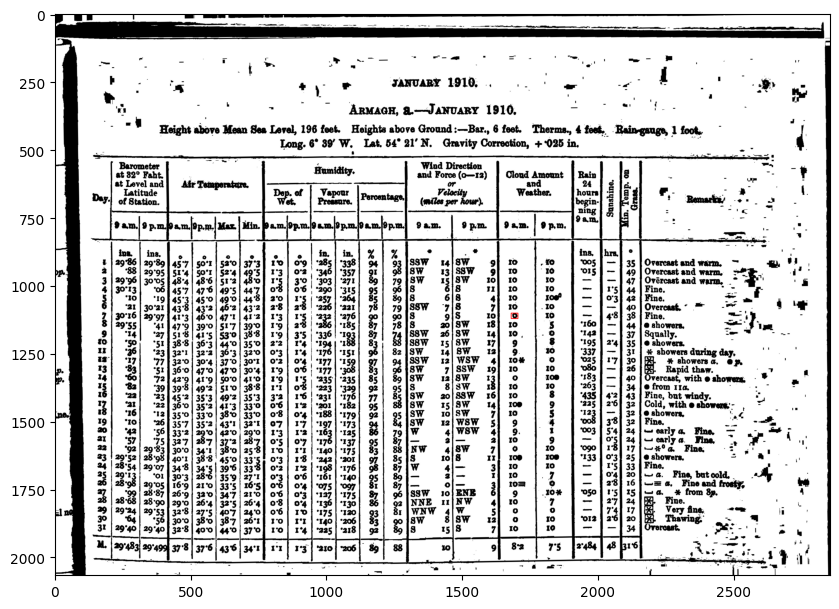

In [14]:
# Here we plot two cells: one representing the minimum cell dimensions and the other the maximum cell dimensions

# Pick a random point in the table
x_min_random =1680
y_min_random = 1101

min_cell_width_threshold = 25
min_cell_height_threshold = 20

binarized_image_in_RGB_min_cell = cv2.cvtColor(binarized_image, cv2.COLOR_GRAY2RGB)
cv2.rectangle(binarized_image_in_RGB_min_cell, (x_min_random, y_min_random), (x_min_random + min_cell_width_threshold, y_min_random + min_cell_height_threshold), (255, 0, 0), 2)
plt.imshow(binarized_image_in_RGB_min_cell)
plt.savefig("results/05_transient_transcription_output/001/min_cell_dimensions", dpi=300)
plt.show()

## See the red box overlayed on the table representing the minimum cell dimensions (min_cell_width_threshold and min_cell_height_threshold)
## If it matches with a small cell, then update the min_cell_width_threshold and min_cell_height_threshold values in the configuration.in of MeteoSaver

You can then do similar checks to estimate space_height_threshold, space_width_threshold and max_cell_height_per_box, or use the values above to estimate them

### Step 4: Automatic Table Detection

#### 4.1 Detect the table label in order to correctly detect the table

In [15]:
!which tesseract

/bin/tesseract


In [16]:
# Modified Table Detection using specific Text (Table label) recognition for Curacao case, as suggested by Teun Peeters-KNMI

## Change the detected text/table label, here "WEERKINDIGE" below

import configparser
import pytesseract
from PIL import Image
import shutil

config = configparser.ConfigParser()
# Adjust path to config.ini (since it's placed in the root directory)
config_file_path = os.path.join('configuration.ini')
config.read(config_file_path)

tesseract_path = config['Transcription']['tesseract_path']

# pytesseract.pytesseract.tesseract_cmd = tesseract_path
pytesseract.pytesseract.tesseract_cmd = shutil.which("tesseract")

img = Image.open(image_path)
data = pytesseract.image_to_data(img, output_type='dict')
boxes = len(data['level'])

for i in range(boxes):
    if data['text'][i] == 'Long.':
        # coordinates of the table label 'Long'. These will be used to detect the location of the table
        print('Below are the detected coordinates and dimensions (x, y, width, height) of the table label "Long":')
        print(data['left'][i], data['top'][i], data['width'][i], data['height'][i], data['text'][i])
        x_coordinate = data['left'][i]
        y_coordinate = data['top'][i]
    
#     else: 
#         x_coordinate = None
#         y_coordinate = None

Below are the detected coordinates and dimensions (x, y, width, height) of the table label "Long":
841 453 91 38 Long.


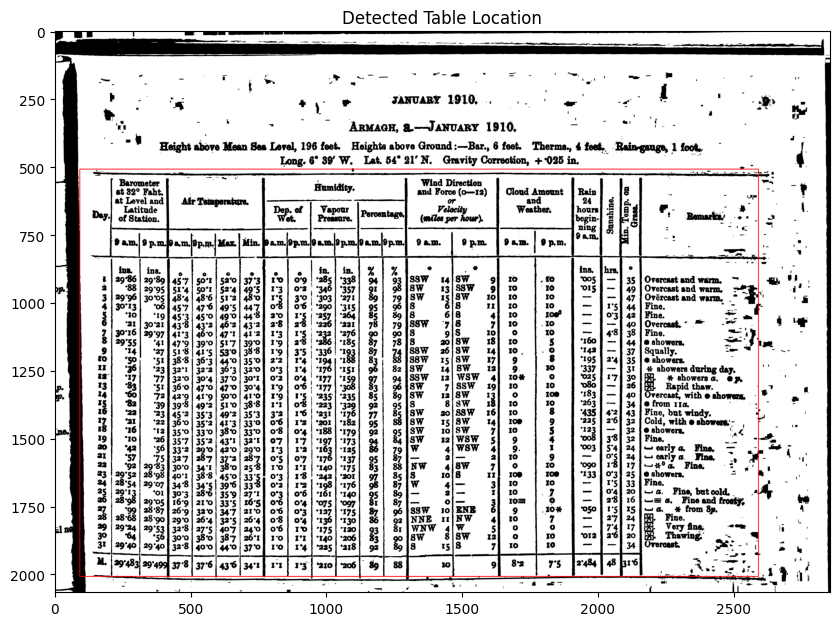

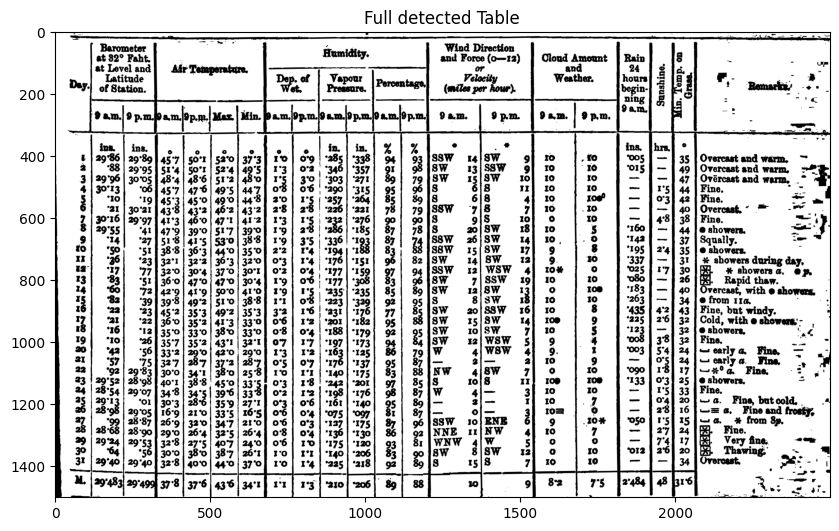

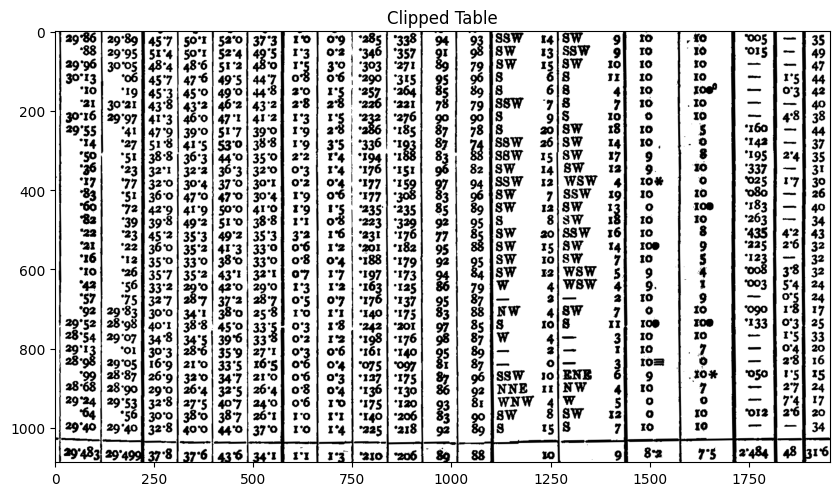

In [17]:
if x_coordinate:
    sway_leftwards = 750  # In pixels. Sway of the Table label 'Long' from the start of the table
    sway_downwards = 55

    table_x_coordinate = x_coordinate - sway_leftwards
    table_y_coordinate = y_coordinate + sway_downwards

    binarized_image_in_RGB = cv2.cvtColor(binarized_image, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(binarized_image_in_RGB, (table_x_coordinate, table_y_coordinate), (table_x_coordinate + max_table_width, table_y_coordinate + max_table_height), (255, 0, 0), 2)
    plt.imshow(binarized_image_in_RGB)
    plt.title('Detected Table Location')
    plt.show()
        
    ## Clip the full table including the row and column labels 
    full_detected_table_with_labels = binarized_image[table_y_coordinate:table_y_coordinate + max_table_height, table_x_coordinate:table_x_coordinate + max_table_width]
    plt.imshow(full_detected_table_with_labels, cmap = 'gray')
    plt.title("Full detected Table")
    plt.show()

    ## Clip the table to only are with values
    table = binarized_image[table_y_coordinate + clip_up:table_y_coordinate + max_table_height - clip_down , table_x_coordinate + clip_left:table_x_coordinate + max_table_width - clip_right]

    plt.imshow(table, cmap ='gray')
    plt.title('Clipped Table')
    plt.show()

else:
    print('No Table detected')

#### 4.2 Detect the horizontal and Vertical Lines of the Table

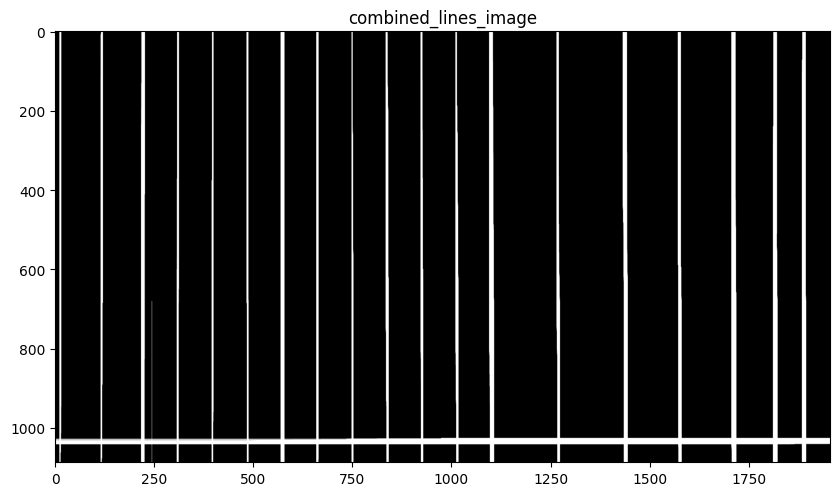

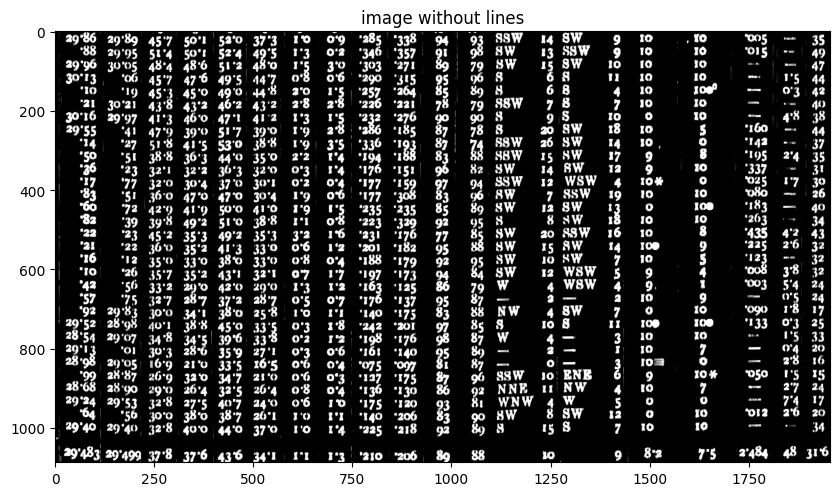

In [18]:
table_img_bin = table # detected table as a binary image

img_bin = 255-table_img_bin

# Detect the vertical lines in the image
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, np.array(table).shape[1]//35)) # The '//50' divides the length of the array (table) by 50, likely to obtain a fraction of the length for the structuring element,
eroded_image = cv2.erode(img_bin, vertical_kernel, iterations=1)
vertical_lines = cv2.dilate(eroded_image, vertical_kernel, iterations=15)

# Detect the horizontal lines in the image
hor_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (np.array(table).shape[1]//25, 1)) # The '//20' divides the width of the array (table) by 20, likely to obtain a fraction of the width for the structuring element.
eroded_image= cv2.erode(img_bin, hor_kernel, iterations=1)
horizontal_lines = cv2.dilate(eroded_image, hor_kernel, iterations=25)

# Blending the images with the vertical lines and the horizontal lines 
combined_vertical_and_horizontal_lines = cv2.addWeighted(vertical_lines, 5, horizontal_lines, 1, 1)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 2))
combined_image_dilated = cv2.dilate(combined_vertical_and_horizontal_lines, kernel, iterations=1)

# Only for visualization purposes. Uncomment the lines below to visualize the detected horizontal and vertical lines in the table
plt.imshow(combined_image_dilated, cmap="gray")
plt.title("combined_lines_image")
plt.show()

# Remove the lines from the image (table)
image_without_lines = cv2.subtract(img_bin, combined_image_dilated)

# Remove smaller 'still-visible' lines through noise removal
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 5))
image_without_lines_noise_removed = cv2.erode(image_without_lines, kernel, iterations=1)
image_without_lines_noise_removed = cv2.dilate(image_without_lines_noise_removed, kernel, iterations=1)
plt.imshow(image_without_lines_noise_removed, cmap = 'gray')
plt.title('image without lines')
plt.show()

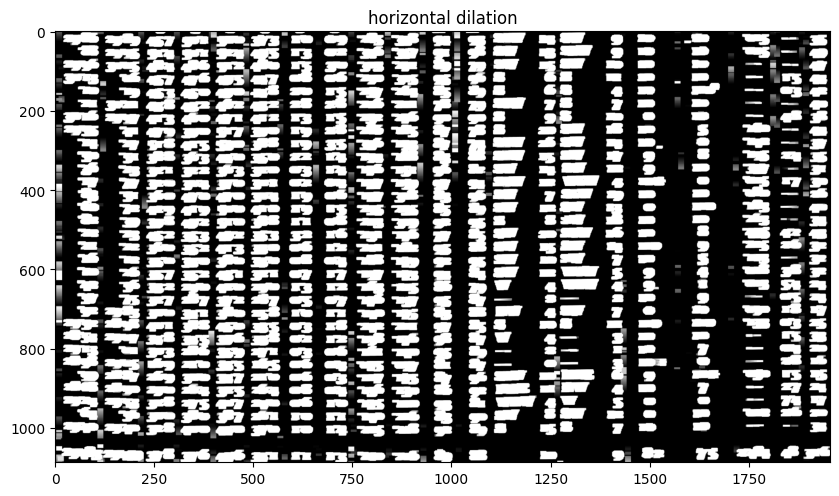

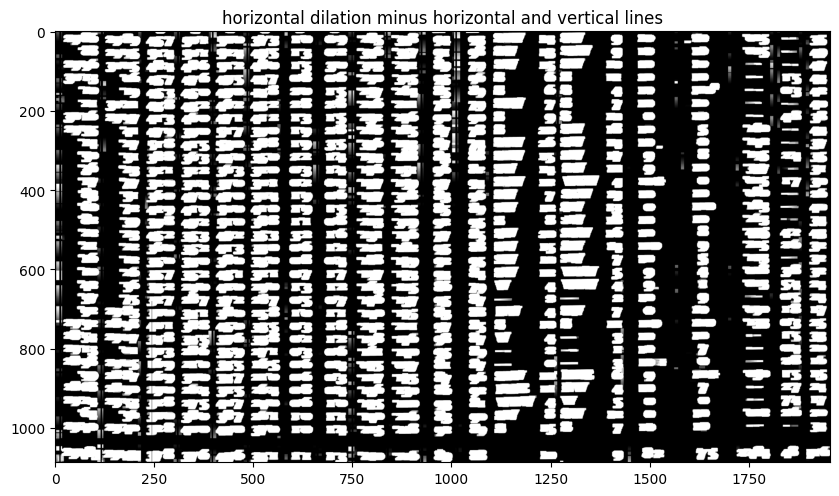

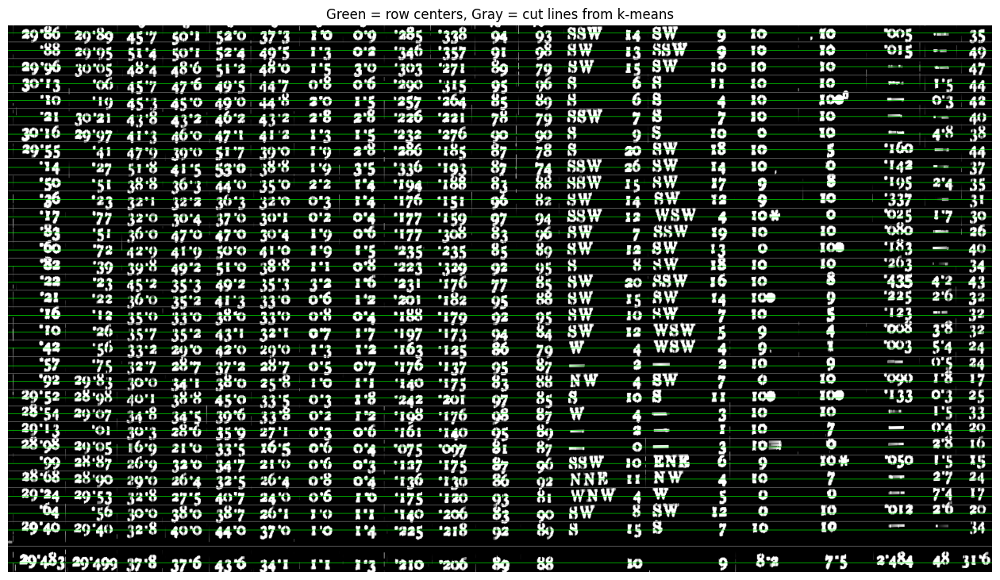

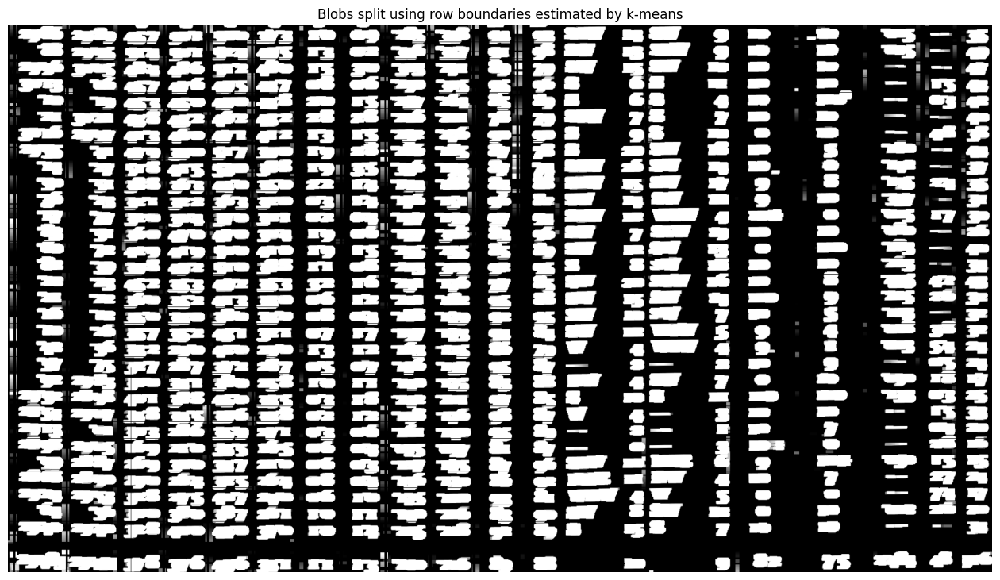

In [19]:
kernel_to_remove_gaps = np.ones((1, 15), np.uint8)  # Horizontal merging kernel. Variables are (Height, Width) in pixels
image_with_number_blobs_dilated = cv2.dilate(image_without_lines_noise_removed, kernel_to_remove_gaps, iterations=1)  # Controlled dilation
# Only for visualization purposes. Uncomment the lines below to visualize the table image showing blobs (text/digit locations)
plt.imshow(image_with_number_blobs_dilated, cmap = 'gray') 
plt.title('horizontal dilation')
plt.show()

image_with_number_blobs_dilated = cv2.subtract(image_with_number_blobs_dilated, combined_image_dilated)
# Only for visualization purposes. Uncomment the lines below to visualize the table image showing blobs (text/digit locations)
plt.imshow(image_with_number_blobs_dilated, cmap = 'gray') 
plt.title('horizontal dilation minus horizontal and vertical lines')
plt.show()


# Get connected components from image without lines
binary = image_without_lines_noise_removed.copy()

num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary, connectivity=8)

min_area = 8
areas = stats[1:, cv2.CC_STAT_AREA]
valid_mask = areas >= min_area
valid_indices = np.where(valid_mask)[0] + 1

x = stats[valid_indices, cv2.CC_STAT_LEFT]
y = stats[valid_indices, cv2.CC_STAT_TOP]
w = stats[valid_indices, cv2.CC_STAT_WIDTH]
h = stats[valid_indices, cv2.CC_STAT_HEIGHT]
area = stats[valid_indices, cv2.CC_STAT_AREA]

cy = y + h / 2.0
cx = x + w / 2.0

# Optional: use only the denser left/middle portion of the table
width_limit = 0.70 * binary.shape[1]
row_mask = cx < width_limit

cy_row = cy[row_mask]
area_row = area[row_mask]


# Weighted k-means on component y-centers
n_rows = 32  # number of rows in the table

# Weight by area, clipped
weights = np.clip((area_row / np.median(area_row)).astype(int), 1, 8)

samples = np.repeat(cy_row, weights).astype(np.float32).reshape(-1, 1)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
attempts = 10

compactness, labels_kmeans, centers = cv2.kmeans(
    samples,
    n_rows,
    None,
    criteria,
    attempts,
    cv2.KMEANS_PP_CENTERS
)

row_centers = np.sort(centers.flatten())

# Midpoints between row centers = cut lines
cut_lines_y = ((row_centers[:-1] + row_centers[1:]) / 2.0).astype(int)

# Visualize row centers and cut lines
vis = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

for yc in row_centers.astype(int):
    cv2.line(vis, (0, yc), (binary.shape[1] - 1, yc), (0, 255, 0), 1)

for yl in cut_lines_y:
    cv2.line(vis, (0, yl), (binary.shape[1] - 1, yl), (128, 128, 128), 1)

plt.figure(figsize=(16, 10))
plt.imshow(vis)
plt.title("Green = row centers, Gray = cut lines from k-means")
plt.axis("off")
plt.show()


# Slice only blobs crossing these cut lines
result = image_with_number_blobs_dilated.copy()

num_labels2, labels2, stats2, _ = cv2.connectedComponentsWithStats(result, connectivity=8)

edge_margin = 3

for i in range(1, num_labels2):
    x2 = stats2[i, cv2.CC_STAT_LEFT]
    y2 = stats2[i, cv2.CC_STAT_TOP]
    w2 = stats2[i, cv2.CC_STAT_WIDTH]
    h2 = stats2[i, cv2.CC_STAT_HEIGHT]

    if w2 == 0 or h2 == 0:
        continue

    roi = result[y2:y2+h2, x2:x2+w2].copy()

    # Keep only cut lines that pass through the blob interior
    internal_cuts = cut_lines_y[(cut_lines_y > y2 + edge_margin) & (cut_lines_y < y2 + h2 - edge_margin)]

    for y_global in internal_cuts:
        y_local = y_global - y2
        cv2.line(roi, (0, y_local), (w2 - 1, y_local), 0, thickness=1)

    result[y2:y2+h2, x2:x2+w2] = roi

plt.figure(figsize=(16, 10))
plt.imshow(result, cmap='gray')
plt.title("Blobs split using row boundaries estimated by k-means")
plt.axis("off")
plt.show()



#### 4.3 Detect and remove the noise such as small dots on our table image (Optional)

In [119]:
# import numpy as np

# # Detect all connected (text) components
# num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(image_without_lines_noise_removed, connectivity=8)

# # Create a mask to keep only valid text components
# filtered_image = np.zeros_like(image_without_lines_noise_removed)

# # Set text thresholds (in pixels)
# ASPECT_RATIO_THRESHOLD = 100   # If e.g Width / Height > 4 (was 4 before this new check), it's considered horizontal noise
# HEIGHT_THRESHOLD = 0  # Remove any blobs with height less than this
# PROXIMITY_THRESHOLD = 0  # Maximum distance (in pixels) to consider a dot "close" to a number

# # Store y-coordinates and x-limits of horizontal dots **ONLY NEAR TEXT**
# horizontal_lines = []

# # Pre-compute aspect ratios for all components
# if num_labels > 1:
#     widths = stats[1:, cv2.CC_STAT_WIDTH]
#     heights = stats[1:, cv2.CC_STAT_HEIGHT]
#     areas = stats[1:, cv2.CC_STAT_AREA]
#     aspect_ratios = widths / heights

#     text_components = []
#     text_labels_to_keep = []
#     dot_labels_to_remove = []

#     # Single loop with pre-computed values
#     for i in range(num_labels - 1):  # Exclude background
#         label_id = i + 1
#         area = areas[i]
#         aspect_ratio = aspect_ratios[i]
#         height = heights[i]

#         # Keep only real text (numbers) as reference components
#         if area > 100 and aspect_ratio < ASPECT_RATIO_THRESHOLD and height > HEIGHT_THRESHOLD:
#             x, y, w, h = stats[label_id, cv2.CC_STAT_LEFT:cv2.CC_STAT_LEFT+4]
#             text_components.append((x, y, w, h))
#             text_labels_to_keep.append(label_id)
#         else:
#             dot_labels_to_remove.append(label_id)

#     # Batch update images
#     if text_labels_to_keep:
#         text_mask = np.isin(labels, text_labels_to_keep)
#         filtered_image[text_mask] = 255

#     dots_to_remove = np.zeros_like(labels)
#     if dot_labels_to_remove:
#         dot_mask = np.isin(labels, dot_labels_to_remove)
#         dots_to_remove[dot_mask] = 255
# else:
#     text_components = []
#     dots_to_remove = np.zeros_like(labels)

# # Pre-convert text_components to numpy arrays for faster operations
# if text_components:
#     text_array = np.array(text_components)  # Shape: (N, 4) for N text components

#     for i in range(1, num_labels):
#         x, y, w, h, area = stats[i, cv2.CC_STAT_LEFT], stats[i, cv2.CC_STAT_TOP], stats[i, cv2.CC_STAT_WIDTH], stats[i, cv2.CC_STAT_HEIGHT], stats[i, cv2.CC_STAT_AREA]
#         aspect_ratio = w / h
#         # Skip already kept text components
#         if area > 100 and aspect_ratio < ASPECT_RATIO_THRESHOLD and h > HEIGHT_THRESHOLD:
#             continue

#         # Vectorized proximity check
#         dot_center_x, dot_center_y = x + w // 2, y + h // 2

#         # Check proximity to all text components at once
#         in_x_range = ((text_array[:, 0] - PROXIMITY_THRESHOLD <= dot_center_x) & 
#                     (dot_center_x <= text_array[:, 0] + text_array[:, 2] + PROXIMITY_THRESHOLD))
#         in_y_range = ((text_array[:, 1] - PROXIMITY_THRESHOLD <= dot_center_y) & 
#                     (dot_center_y <= text_array[:, 1] + text_array[:, 3] + PROXIMITY_THRESHOLD))

#         keep_dot = np.any(in_x_range & in_y_range)

#         if keep_dot:
#             filtered_image[labels == i] = 255
#             horizontal_lines.append((dot_center_y, x, x + w))

# # Only for visualization purposes. Uncomment the lines below to visualize the filtered table image showing text/digits without the noise such as dots.
# plt.imshow(filtered_image, cmap="gray")
# plt.title("Second Filtered Image - Only Dots Near Text - No Lines")
# plt.show()

#### 4.5 Arranging the detected blobs, here cells, into rows and columns ready for the next transcription module

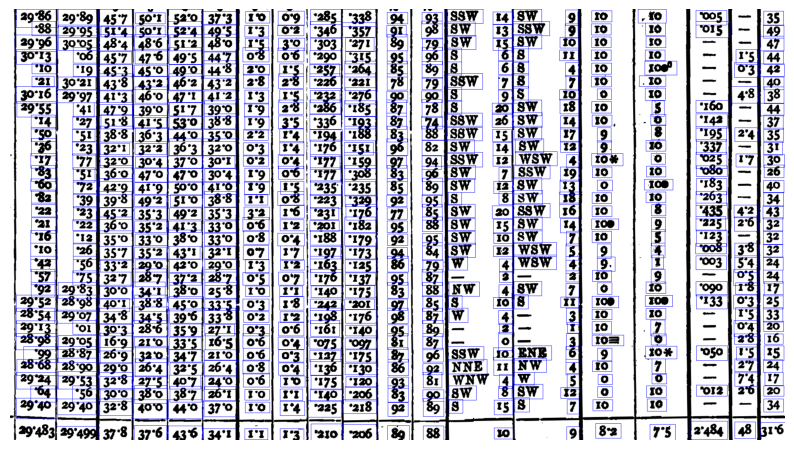

In [20]:
def filter_contours(contours, min_width_threshold, min_height_threshold, max_width_threshold, max_height_threshold):
    '''
    Filters a list of contours based on specified width and height thresholds.

    This function takes a list of contours and filters them by their bounding rectangle dimensions. Contours whose bounding rectangles fall within the specified width and height thresholds are retained, while others are discarded. This is useful for removing noise or irrelevant contours based on size constraints e.g. small contours that don't contain text or very large contours that cover more than one cell.

    Parameters
    --------------
    contours : list
        A list of contours, where each contour is an array of points defining the contour's shape.
    
    min_width_threshold : int
        The minimum width (in pixels) that a contour's bounding rectangle must have to be included in the filtered results.
    
    min_height_threshold : int
        The minimum height (in pixels) that a contour's bounding rectangle must have to be included in the filtered results.
    
    max_width_threshold : int
        The maximum width (in pixels) that a contour's bounding rectangle can have to be included in the filtered results.
    
    max_height_threshold : int
        The maximum height (in pixels) that a contour's bounding rectangle can have to be included in the filtered results.

    Returns
    --------------
    filtered_contours : list of bounding boxes (filtered)
        A list of contours that meet the specified width and height criteria. Contours whose bounding rectangles do not fall within the given thresholds are excluded.
    '''

    filtered_contours = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if min_width_threshold <= w <= max_width_threshold and min_height_threshold <= h <= max_height_threshold:
            filtered_contours.append(contour)
    return filtered_contours


## STEP 5: ARRANGING THE DETECTED BLOBS, HERE CELLS, INTO ROWS AND COLUMNS READY FOR THE NEXT TRANSCRIPTION MODULE
## Here we draw contours around the remaining detected blobs in order to detect text in the table
contour_result = cv2.findContours(result.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
contours = contour_result[0]
# result = cv2.findContours(result, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
# contours = result[0]

# Make a copy of the original image to overlay contours without modifying the original
table_img_bin_overlayed_with_contours = table_img_bin.copy()
# Convert the grayscale image to RGB to support colored bounding boxes
table_img_bin_overlayed_with_contours = cv2.cvtColor(table_img_bin_overlayed_with_contours, cv2.COLOR_GRAY2RGB)

# Filter out smaller or larger bounding boxes from all the detected text contours. This is helpful to avoid overly large cells or small cells with no text. Remember to adjust these values for (min_cell_width_threshold, min_cell_height_threshold, max_cell_width_threshold, max_cell_height_threshold) based on the table structure in your specific case in the configutation.ini file.
filtered_contours = filter_contours(contours, min_cell_width_threshold, min_cell_height_threshold, max_cell_width_threshold, max_cell_height_threshold)

# Iterate over each contour in the new_contours list and draw bounding boxes
for contour in filtered_contours:
    if contour is not None and len(contour) > 0:
        x, y, w, h = cv2.boundingRect(contour) # Dimensions of the rectangular countours surrounding the blobs. We term these as bounding boxes. 

        # # Adjust bounding box dimensions
        # Define increase factors for bounding box modification. We do this to give more room to the detected cell and avoid cutting the text in the cells.
        increase_factor_width = 0.1  # Increase width by 7%
        increase_factor_height = 0.15  # Increase height by 20%

        # Expand width while keeping it centered
        new_w = int(w * (1 + increase_factor_width))  # Increase width
        x = max(0, x - (new_w - w) // 2)  # Adjust x to keep center fixed

        # Expand height symmetrically
        new_h = int(h * (1 + increase_factor_height * 2))  # Increase height
        y = max(0, y - (new_h - h) // 2)  # Adjust y to keep center fixed

        # Ensure bounding box remains within valid image bounds
        x = max(0, x)
        y = max(0, y)
        w = max(1, new_w)  # Avoid zero or negative width
        h = max(1, new_h)  # Avoid zero or negative height

        # Draw the bounding box directly on the overlay image
        cv2.rectangle(table_img_bin_overlayed_with_contours, (x, y), (x + w, y + h), (0, 0, 255), 1)

# Only for visualization purposes. Display the image with bounding boxes using matplotlib
plt.imshow(table_img_bin_overlayed_with_contours)
plt.axis('off')  # Hide axis
plt.savefig("results/05_transient_transcription_output/001/detected_cells", dpi=300)
plt.show()

# Sort contours by y-coordinate
contours_sorted = sorted(filtered_contours, key=lambda c: cv2.boundingRect(c)[1])

#### 4.6 Remove any noise (such as dots) from the binarized image of the table to prepare it for the next transcription module

Optional: 

In [72]:
# ## STEP 6: REMOVE ANY NOISE (SUCH AS DOTS) FROM THE BINARIZED IMAGE OF THE TABLE TO PREPARE IT FOR THE NEXT TRANSCRIPTION MODULE
# # Apply the same dot removal to the **binarized image**
# table_img_bin[dots_to_remove == 255] = 255  # Set dots to white

# # Ensure the image is strictly binary
# table_img_bin[table_img_bin > 127] = 255  # Set everything above 127 to white
# table_img_bin[table_img_bin <= 127] = 0   # Set everything below 127 to black

# # # Save the binary image for use later in detecting text
# # save_dir = os.path.join(transient_transcription_output_dir, station)
# # os.makedirs(save_dir, exist_ok=True)  # Ensure the directory exists
# # save_path_without_dots = os.path.join(save_dir, 'table_binarized_without_dots.jpg')
# # cv2.imwrite(save_path_without_dots, table_img_bin)

# # Only for visualization purposes. show the binarized image of the table without any noise such as dots.
# # Original image of table in binarized format without the dots
# table_binarized_without_dots = table_img_bin.copy()
# plt.imshow(table_binarized_without_dots, cmap ='gray')
# plt.title("Filtered Image - Text Only - Without dots")
# plt.show()

# table_for_overlaying_with_contours = table_img_bin.copy()
# # Convert the grayscale image to RGB to support colored bounding boxes
# table_for_overlaying_with_contours = cv2.cvtColor(table_for_overlaying_with_contours, cv2.COLOR_GRAY2RGB)
# detected_table_cells = [contours_sorted, image_with_all_bounding_boxes, table_for_overlaying_with_contours, table_original_image, full_detected_table_with_labels]



In [21]:
## Save binary image for use later 
save_dir = "results/05_transient_transcription_output/"  ## change this to your preferred directory. See INFO in the commented line below
#When using MeteoSaver as a whole, not like in this example JUPYTER Notebook, this is a directory above is automaticaly set as your transient_transcription_output_dir  per station 

os.makedirs(save_dir, exist_ok=True)  # Ensure the directory exists
save_path = os.path.join(save_dir, 'table_binarized.jpg')
cv2.imwrite(save_path, table_img_bin)
save_path = os.path.join(save_dir, 'table_binarized.jpg')


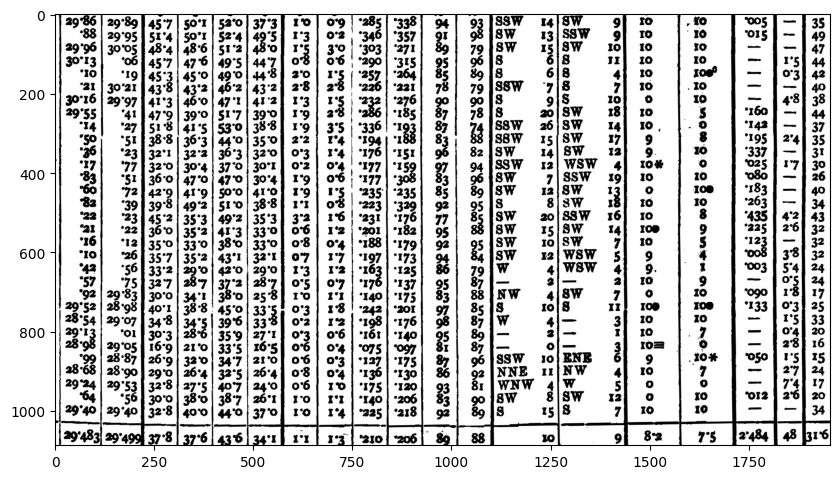

In [22]:
image_with_all_bounding_boxes = cv2.imread(save_path)

plt.imshow(image_with_all_bounding_boxes, 'gray')

table_for_overlaying_with_contours = table_img_bin.copy()
# Convert the grayscale image to RGB to support colored bounding boxes
table_for_overlaying_with_contours = cv2.cvtColor(table_for_overlaying_with_contours, cv2.COLOR_GRAY2RGB)

detected_table_and_cells =[contours_sorted, image_with_all_bounding_boxes, table_for_overlaying_with_contours, table, full_detected_table_with_labels]


### Step 5: Transcription

In [40]:
import os, argparse, glob, tempfile, shutil, warnings
import cv2
import openpyxl
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles import Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
from openpyxl.utils import column_index_from_string
# from paddleocr import PaddleOCR,draw_ocr
from PIL import Image, ImageDraw, ImageFont
import pytesseract
from bidi.algorithm import get_display
import easyocr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import math
import random
from scipy.stats import trim_mean
from scipy.cluster.hierarchy import fcluster, linkage
from sklearn.cluster import DBSCAN
from datetime import datetime
from calendar import monthrange
import zipfile


def get_max_rows_from_filename(filename):
    """ Extract year and month from filename and determine max rows. """
    try:
        # Extract YYYYMMDD part from filename (assuming format: STN_YYYYMMDD_SF)
        parts = filename.split('_')  # Splitting by '_'
        if len(parts) < 3:
            raise ValueError("Unexpected filename format")

        date_part = parts[1]  # Extract YYYYMMDD
        year = int(date_part[:4])  # First 4 characters = Year
        month = int(date_part[4:6])  # Next 2 characters = Month
        
        # Get the number of days in the month (handles leap years)
        num_days = monthrange(year, month)[1]

        # Calculate max_rows dynamically
        max_rows = num_days + 6  # Adding 5-day totals & averages
        
        return max_rows
    except Exception as e:
        print(f"Error processing filename {filename}: {e}")
        return 37  # Default to the max value (31 days)


def organize_contours_midpoint(contours, filename):
    """
    Organizes contours into `max_rows` using **midpoint clustering**, ensuring:
    - The row median is calculated using only the **50% closest** boxes.
    - Misaligned boxes are reassigned to the best row.
    - No row has more than `max_columns` boxes.

    Parameters:
    --------------
    contours: list
        List of bounding boxes (contours) detected in the image.

    max_rows: int
        Expected number of rows.

    max_columns: int
        Expected number of columns.

    Returns:
    --------------
    sorted_rows: list of lists
        Bounding boxes grouped into ordered rows.
    """

    if not contours:
        return []

    # Step 1: Extract **midpoint y-coordinates** for clustering
    midpoints = np.array([cv2.boundingRect(c)[1] + cv2.boundingRect(c)[3] // 2 for c in contours]).reshape(-1, 1)

    # Step 2: Perform K-Means clustering on midpoints
#     max_rows = get_max_rows_from_filename(filename)
    max_rows = 32
    kmeans = KMeans(n_clusters=min(max_rows, len(midpoints)), random_state=0, n_init=50, tol=1e-2)
    kmeans.fit(midpoints)
    labels = kmeans.labels_

    # Step 3: Assign contours to rows based on clustering
    row_dict = {i: [] for i in range(max_rows)}
    for label, contour in zip(labels, contours):
        row_dict[label].append(contour)

    # Step 4: Compute **super strict row medians** using only the closest 50%
    row_medians = {}

    for i, row in row_dict.items():
        if len(row) > 2:
            y_mids = np.array([cv2.boundingRect(c)[1] + cv2.boundingRect(c)[3] // 2 for c in row])
            y_mids.sort()

            # Keep **only the middle 50% closest values**
            trimmed_y_mids = y_mids[len(y_mids) // 4 : 3 * len(y_mids) // 4]

            # Compute median of the **trimmed** values
            row_medians[i] = np.median(trimmed_y_mids)
        else:
            row_medians[i] = np.median([cv2.boundingRect(c)[1] + cv2.boundingRect(c)[3] // 2 for c in row])

    # Step 5: Move misplaced boxes to the best row
    adjusted_rows = {i: [] for i in range(max_rows)}

    for i, row in row_dict.items():
        for box in row:
            y_mid = cv2.boundingRect(box)[1] + cv2.boundingRect(box)[3] // 2  # **Midpoint y-coordinate**
            
            # Find closest **trusted** row median (ignoring outliers)
            closest_row = i
            min_distance = abs(y_mid - row_medians[i])

            if i > 0:  # Check row above
                distance_up = abs(y_mid - row_medians[i-1])
                if distance_up < min_distance:
                    min_distance = distance_up
                    closest_row = i-1

            if i < max_rows - 1:  # Check row below
                distance_down = abs(y_mid - row_medians[i+1])
                if distance_down < min_distance:
                    closest_row = i+1

            adjusted_rows[closest_row].append(box)

    # Step 6: Sort each adjusted row again (left to right)
    for i in range(len(adjusted_rows)):
        adjusted_rows[i] = sorted(adjusted_rows[i], key=lambda c: cv2.boundingRect(c)[0])

    # Convert to final sorted list
    sorted_rows = [adjusted_rows[i] for i in range(max_rows)]

    return sorted_rows


def organize_contours_top(contours, filename):
    """
    Organizes contours into `max_rows` using **top edge clustering**, ensuring:
    - The row median is calculated using only the **50% closest** boxes.
    - Misaligned boxes are reassigned to the best row.
    - No row has more than `max_columns` boxes.

    Parameters:
    --------------
    contours: list
        List of bounding boxes (contours) detected in the image.

    max_rows: int
        Expected number of rows.

    max_columns: int
        Expected number of columns.

    Returns:
    --------------
    sorted_rows: list of lists
        Bounding boxes grouped into ordered rows.
    """

    if not contours:
        return []

    # Step 1: Extract **top edge y-coordinates** for clustering
    top_edges = np.array([cv2.boundingRect(c)[1] for c in contours]).reshape(-1, 1)

    # Step 2: Perform K-Means clustering on top edges
#     max_rows = get_max_rows_from_filename(filename)
    max_rows = 32
    kmeans = KMeans(n_clusters=min(max_rows, len(top_edges)), random_state=0, n_init=50, tol=1e-2)
    kmeans.fit(top_edges)
    labels = kmeans.labels_

    # Step 3: Assign contours to rows based on clustering
    row_dict = {i: [] for i in range(max_rows)}
    for label, contour in zip(labels, contours):
        row_dict[label].append(contour)

    # Step 4: Compute **super strict row medians** using only the closest 50%
    row_medians = {}

    for i, row in row_dict.items():
        if len(row) > 2:
            y_tops = np.array([cv2.boundingRect(c)[1] for c in row])
            y_tops.sort()

            # Keep **only the middle 50% closest values**
            trimmed_y_tops = y_tops[len(y_tops) // 4 : 3 * len(y_tops) // 4]

            # Compute median of the **trimmed** values
            row_medians[i] = np.median(trimmed_y_tops)
        else:
            row_medians[i] = np.median([cv2.boundingRect(c)[1] for c in row])

    # Step 5: Move misplaced boxes to the best row
    adjusted_rows = {i: [] for i in range(max_rows)}

    for i, row in row_dict.items():
        for box in row:
            y_top = cv2.boundingRect(box)[1]  # **Top edge y-coordinate**
            
            # Find closest **trusted** row median (ignoring outliers)
            closest_row = i
            min_distance = abs(y_top - row_medians[i])

            if i > 0:  # Check row above
                distance_up = abs(y_top - row_medians[i-1])
                if distance_up < min_distance:
                    min_distance = distance_up
                    closest_row = i-1

            if i < max_rows - 1:  # Check row below
                distance_down = abs(y_top - row_medians[i+1])
                if distance_down < min_distance:
                    closest_row = i+1

            adjusted_rows[closest_row].append(box)

    # Step 6: Sort each adjusted row again (left to right)
    for i in range(len(adjusted_rows)):
        adjusted_rows[i] = sorted(adjusted_rows[i], key=lambda c: cv2.boundingRect(c)[0])

    # Convert to final sorted list
    sorted_rows = [adjusted_rows[i] for i in range(max_rows)]

    return sorted_rows




def organize_contours_fraction(contours, max_rows, fraction=0.33):
    '''
    Organizes the bounding boxes (contours) in rows by a fractional point between the top and midpoint using KMeans clustering.

    Parameters
    --------------
    contours: list of bounding boxes (with their x, y, w, h coordinates)
        List of contours for the detected text in the table cells with coordinates.

    max_rows: int
        Maximum rows, adjusted based on your table's expected structure.

    fraction: float, optional (default=0.33)
        The fractional point of the height from the top for vertical clustering. A value between 0 (top) and 1 (bottom).
    
    Returns
    --------------
    rows: Bounding boxes organized in rows using KMeans clustering.
    '''

    # Calculate the point at the specified fraction between the top and bottom
    fraction_points = [(cv2.boundingRect(contour)[1] + int(cv2.boundingRect(contour)[3] * fraction)) for contour in contours]
    
    if len(fraction_points) == 0:
        return []

    # Apply KMeans clustering based on the fractional points
    kmeans = KMeans(n_clusters=min(max_rows, len(fraction_points)), random_state=0)
    kmeans.fit(np.array(fraction_points).reshape(-1, 1))
    labels = kmeans.labels_

    rows = [[] for _ in range(max_rows)]
    for label, contour in zip(labels, contours):
        rows[label].append(contour)

    # Sort each row by the x-coordinate for left-to-right ordering within rows
    for i in range(len(rows)):
        rows[i] = sorted(rows[i], key=lambda c: cv2.boundingRect(c)[0])

    return rows


def get_kmeans_column_centers(contours, no_of_columns):
    """
    Learn column x-center positions from all detected contours.
    """
    x_centers = []

    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        x_center = x + (w / 2)
        x_centers.append([x_center])

    x_centers = np.array(x_centers, dtype=np.float32)

    if len(x_centers) < no_of_columns:
        raise ValueError(
            f"Not enough detected cells ({len(x_centers)}) for {no_of_columns} columns."
        )

    kmeans = KMeans(n_clusters=no_of_columns, random_state=42, n_init=10)
    kmeans.fit(x_centers)

    column_centers = np.sort(kmeans.cluster_centers_.flatten())

    return column_centers

def calculate_cell_reference(x, w, row_index, assigned_columns_per_row,
                             max_columns, table_width):
    """
    Assign cell to nearest KMeans-derived column center.
    The column centers must already be stored in:
        assigned_columns_per_row["_column_centers"]
    """

    x_center = x + (w / 2)

    column_centers = assigned_columns_per_row["_column_centers"]

    # nearest learned column
    column = int(np.argmin(np.abs(column_centers - x_center))) + 1

    # ensure row exists
    if row_index not in assigned_columns_per_row:
        assigned_columns_per_row[row_index] = set()

    # if this column is already taken in the same row,
    # assign the nearest free column instead
    if column in assigned_columns_per_row[row_index]:
        candidate_columns = list(range(1, max_columns + 1))
        candidate_columns.sort(key=lambda c: abs(c - column))

        for c in candidate_columns:
            if c not in assigned_columns_per_row[row_index]:
                column = c
                break

    column = max(1, min(column, max_columns))

    assigned_columns_per_row[row_index].add(column)

    return f"{openpyxl.utils.get_column_letter(column)}{row_index}"

# def calculate_cell_reference(x, w, row_index, assigned_columns_per_row, max_columns, table_width):
#     '''
#     Ensures that there is always only one box per column by tracking assigned columns.

#     If two cells are assigned to the same column, the second one is moved to the next available column.

#     Parameters
#     --------------
#     x : float or int
#         The x-coordinate of the cell's **top-left** corner.
    
#     w : float or int
#         The width of the bounding box.
    
#     row_index : int
#         The row number in the table to which the cell belongs.
    
#     max_columns : int
#         The maximum number of columns in the table. Ensures the column index does not exceed limits.
    
#     table_width : int or float
#         The total width of the table (in pixels). Used to determine the relative position of `x_center` 
#         within the table and calculate the corresponding column index.

#     assigned_columns_per_row : dict
#         A dictionary tracking assigned columns for each row to ensure uniqueness.

#     Returns
#     --------------
#     cell_reference : str
#         The Excel-style cell reference (e.g., 'B3', 'C7') corresponding to the detected cell's position within the table.
#     '''

#     # Use the **center top x-coordinate** instead of just `x`
#     x_center = x + (w / 2)

#     # Calculate column index based on x_center instead of x
#     column = math.floor(x_center / table_width * max_columns) + 1
    
# #     # Use the **most left top x-coordinate**
# #     # Calculate column index based on x_center instead of x
# #     column = math.floor(x / table_width * max_columns) + 1

# #     # Ensure the column index is within valid ranges
# #     column = max(1, min(column, max_columns))

#     # Ensure the row exists in the tracking dictionary
#     if row_index not in assigned_columns_per_row:
#         assigned_columns_per_row[row_index] = set()

# #     # If the column is already assigned, shift to the next available column
# #     while column in assigned_columns_per_row[row_index] and column <= max_columns:
# #         column += 1  # Move to the next column

# #     # Ensure the new column is within range
# #     column = min(column, max_columns)

#     # Register the assigned column
#     assigned_columns_per_row[row_index].add(column)

#     return f'{openpyxl.utils.get_column_letter(column)}{row_index}'



# def calculate_cell_reference(x, y, w, max_columns, max_rows, table_height, table_width):
#     '''
#     Ensures that there is always only one box per column by tracking assigned columns.

#     If two cells are assigned to the same column, the second one is moved to the next available column.

#     Parameters
#     --------------
#     x : float or int
#         The x-coordinate of the cell's **top-left** corner.
    
#     w : float or int
#         The width of the bounding box.
    
#     row_index : int
#         The row number in the table to which the cell belongs.
    
#     max_columns : int
#         The maximum number of columns in the table. Ensures the column index does not exceed limits.
    
#     table_width : int or float
#         The total width of the table (in pixels). Used to determine the relative position of `x_center` 
#         within the table and calculate the corresponding column index.

#     assigned_columns_per_row : dict
#         A dictionary tracking assigned columns for each row to ensure uniqueness.

#     Returns
#     --------------
#     cell_reference : str
#         The Excel-style cell reference (e.g., 'B3', 'C7') corresponding to the detected cell's position within the table.
#     '''

# #     # Use the **center top x-coordinate** instead of just `x`
# #     x_center = x + (w / 2)

# #     # Calculate column index based on x_center instead of x
# #     column = math.floor(x_center / table_width * max_columns) + 1
    
#     # Use the **most left top x-coordinate**
#     # Calculate column index based on x_center instead of x
#     column = math.floor(x / table_width * max_columns) + 1

#     # Ensure the column index is within valid ranges
#     column = max(1, min(column, max_columns))
    
#     row_index = math.floor(y/ table_height * max_rows) + 1
    
#     row_index = max(1, min(row_index, max_rows))


#     return f'{openpyxl.utils.get_column_letter(column)}{row_index}'




# def calculate_cell_reference(
#     x, y, w,
#     row_index,
#     max_columns,
#     table_width,
#     reset=False,
#     eps=1e-6
# ):
#     """
#     Determines the Excel-style cell reference (e.g., 'C7') for a detected cell
#     using only its x-position (horizontal location) to find the correct column.
#     The row_index is passed directly (since rows are already sorted).

#     Features:
#     - Uses nearest bin center along x-axis (robust to uneven cell widths)
#     - If a column in the same row is already occupied, the new cell overwrites it
#     - Maintains internal state; call once with reset=True for each new table
#     """

#     # ---- initialize or reset internal state ----
#     if reset or not hasattr(calculate_cell_reference, "_state"):
#         calculate_cell_reference._state = {}

#     state = calculate_cell_reference._state
#     key = (int(max_columns), int(table_width))
#     if reset or key not in state:
#         C = int(max_columns)
#         col_edges = np.linspace(0.0, 1.0, C + 1)
#         col_centers = 0.5 * (col_edges[:-1] + col_edges[1:])
#         occ = {}  # row_index -> {col: distance_to_center}
#         state[key] = {
#             "C": C,
#             "W": float(table_width),
#             "col_edges": col_edges,
#             "col_centers": col_centers,
#             "occ": occ
#         }

#     S = state[key]
#     C = S["C"]
#     W = S["W"]
#     col_edges = S["col_edges"]
#     col_centers = S["col_centers"]
#     occ = S["occ"]

#     # ---- helper: find which column this x-center belongs to ----
#     def snap_to_column(rel_center):
#         rel_center = min(max(rel_center, 0.0 + eps), 1.0 - eps)
#         col_idx = int(np.digitize(rel_center, col_edges[1:-1], right=False)) + 1
#         col_idx = max(1, min(col_idx, C))
#         dist = abs(rel_center - col_centers[col_idx - 1])
#         return col_idx, dist

#     # ---- determine column index from x only ----
#     cx = (x + 0.5 * w) / W  # normalized x-center
#     col, col_dist = snap_to_column(cx)

#     # ---- record (overwrite) this cell assignment ----
#     if row_index not in occ:
#         occ[row_index] = {}

#     # Always overwrite previous cell in this (row, col)
#     occ[row_index][col] = col_dist

#     # ---- return Excel-style cell reference ----
#     return f"{openpyxl.utils.get_column_letter(col)}{row_index}"


def generate_random_colors(n):
    '''
    Generates a list of `n` random distinct colors in BGR format.

    This function creates a list of distinct colors by generating random values for hue, saturation, and value (HSV) and then converting them to the BGR color space, which is commonly used in OpenCV. The generated colors are vivid and bright, ensuring they are visually distinct when used in applications such as object detection, image segmentation, or visual annotations.

    Parameters
    --------------
    n : int
        The number of distinct colors to generate.

    Returns
    --------------
    colors : list of tuples
        A list containing `n` tuples, each representing a color in BGR format. The colors are designed to be vivid and distinct for clear visualization.
    '''


    colors = []
    for i in range(n):
        # Generate random values for hue, saturation, and value
        hue = random.randint(0, 179)  # Hue range in OpenCV is [0, 179]
        saturation = random.randint(100, 255)  # To ensure the colors are vivid
        value = random.randint(100, 255)  # To ensure the colors are bright

        # Convert the random HSV color to BGR
        color = cv2.cvtColor(np.uint8([[[hue, saturation, value]]]), cv2.COLOR_HSV2BGR)[0][0].tolist()
        colors.append((int(color[0]), int(color[1]), int(color[2])))
    return colors


def draw_row_markers_and_boxes(image, rows, colors):
    '''
    Draws bounding boxes around contours in each row and adds numbered markers to each row with distinct colors.
    Ensures numbering is continuous (1 to 43), even for None rows.
    '''

    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.5
    thickness = 1

    for idx in range(len(rows)):  # Iterate over full 43-row structure
        row = rows[idx]  # Get row (can be None)
        color = colors[idx % len(colors)]  # Cycle through colors if needed

        y_position = 50 + (idx * 62)  # Approximate vertical position based on row index
        x_position = 10  # Arbitrary x position for marker

        # Always number rows, even if None
        cv2.putText(image, str(idx + 1), (x_position, y_position), font, font_scale, color, thickness)

        if row is None:
            continue  # Skip drawing bounding boxes for None rows

        # Draw bounding boxes for each contour in the row
        for contour in row:
            x, y, w, h = cv2.boundingRect(contour)

            # Define increase factors for bounding box modification
            increase_factor_width = 0.07  # 
            increase_factor_height = 0.35  # 

            # Expand width while keeping it centered
            new_w = int(w * (1 + increase_factor_width))  # Increase width
            x = max(0, x - (new_w - w) // 2)  # Adjust x to keep center fixed

            # Expand height symmetrically
            new_h = int(h * (1 + increase_factor_height * 2))  # Increase height
            y = max(0, y - (new_h - h) // 2)  # Adjust y to keep center fixed

            # Ensure bounding box remains within valid image bounds
            x = max(0, x)
            y = max(0, y)
            w = max(1, new_w)  # Avoid zero or negative width
            h = max(1, new_h)  # Avoid zero or negative height

            # Draw bounding box on the visualization image
            cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)



def calculate_trimmed_mean(values, proportion_to_cut=0.2):
    '''
    Calculates the trimmed mean of a list of values, excluding a specified proportion of the smallest and largest values.

    This function computes the trimmed mean of a given list of numerical values. The trimmed mean is a measure of central tendency that removes a certain proportion of the lowest and highest values before calculating the mean. This helps to reduce the effect of outliers on the mean.

    Parameters
    --------------
    values : list
        A list of numerical values for which the trimmed mean is to be calculated.
    
    proportion_to_cut : float, optional
        The proportion of values to remove from each end of the sorted list before calculating the mean. 
        For example, a proportion of 0.2 means removing the lowest 20% and the highest 20% of the values. 
        The default value is 0.2.

    Returns
    --------------
    float
        The trimmed mean of the input values, after excluding the specified proportion of extreme values.
    '''

    return trim_mean(values, proportion_to_cut)


def merge_excel_files(file1, file2, output_file, start_row, end_row):
    '''
    Merges two Excel files for verification purposes: one organized by the mid-point coordinates of bounding boxes and the other by the top coordinates.

    This function merges two preprocessed Excel files that contain transcribed data organized differently (one by mid-point and the other by top coordinates of bounding boxes). 
    The merged output file allows for cross-checking to ensure that cells are correctly placed in their respective rows.

    Parameters
    --------------
    file1: str
        The path to the Excel file containing transcribed data organized in rows using the top coordinates of the bounding boxes (contours).
    file2: str
        The path to the Excel file containing transcribed data organized in rows using the mid-point coordinates of the bounding boxes (contours).
    output_file: str
        The path where the merged Excel file will be saved.
    start_row: int
        The starting row number from which to begin the merge.
    end_row: int
        The ending row number up to which the merge should be conducted.

    Returns
    --------------
    None
        The function creates and saves a merged Excel file at the specified `output_file` location. This file combines the data from `file1` and `file2` for further verification.
    '''


    # Load the Excel files into DataFrames without headers
    df1 = pd.read_excel(file1, header=None)
    df2 = pd.read_excel(file2, header=None)


    # If the indices are not simple integers or do not align with Excel rows as expected,
    # you might need to reset them or adjust how the Excel file is being read (e.g., `index_col=None`)
    df1 = df1.reset_index(drop=True)
    df2 = df2.reset_index(drop=True)

    # Convert start_row and end_row to zero-based index for Python
    start_idx = start_row - 1  # Convert 1-based index to 0-based
    end_idx = end_row - 1  # Convert 1-based index to 0-based

    # Slice to only include the range from start_idx to end_idx
    df1 = df1.iloc[start_idx:end_idx + 1]
    df2 = df2.iloc[start_idx:end_idx + 1]

    # Initialize a new DataFrame to hold merged results
    merged_df = pd.DataFrame(index=df1.index, columns=df1.columns)

    # Iterate over rows by index (assuming the indices are aligned)
    for idx in df1.index:
        for col in df1.columns:
            val1 = df1.at[idx, col]
            val2 = df2.at[idx, col]
            # Simple merge logic: prefer non-empty values from df1, then df2
            if pd.notna(val1):
                merged_df.at[idx, col] = val1
            else:
                merged_df.at[idx, col] = val2


    # Create a new workbook and select the active worksheet
    new_workbook = openpyxl.Workbook()
    new_worksheet = new_workbook.active

    # Append the merged DataFrame to the new worksheet
    for r_idx, row in enumerate(dataframe_to_rows(merged_df, index=False, header=False), start=1):
        for c_idx, value in enumerate(row, start=1):
            new_worksheet.cell(row=r_idx, column=c_idx, value=value)

    # Merge cells for multi-column headers
    ws.merge_cells(start_row=1, start_column=1, end_row=3, end_column=1) #Day
    ws.merge_cells(start_row=1, start_column=2, end_row=2, end_column=3) #Barmometer...
    ws.merge_cells(start_row=1, start_column=4, end_row=2, end_column=7) #Air Temperature
    ws.merge_cells(start_row=1, start_column=8, end_row=1, end_column=13) #Humidity
    ws.merge_cells(start_row=1, start_column=14, end_row=2, end_column=17) #Wind Direction and Force...
    ws.merge_cells(start_row=1, start_column=18, end_row=2, end_column=19) #Cloud Amount and Weather
    ws.merge_cells(start_row=1, start_column=20, end_row=3, end_column=20) #Rain 24 hours...
    ws.merge_cells(start_row=1, start_column=21, end_row=3, end_column=21) #Sunshine
    ws.merge_cells(start_row=1, start_column=22, end_row=3, end_column=22) #Min. Temp. on Grass
    ws.merge_cells(start_row=1, start_column=23, end_row=3, end_column=23) #Remarks
    # subheaders 1
    ws.merge_cells(start_row=2, start_column=8, end_row=2, end_column=9) #Dep. of Wet
    ws.merge_cells(start_row=2, start_column=10, end_row=2, end_column=11) #Vapour pressure
    ws.merge_cells(start_row=2, start_column=12, end_row=2, end_column=13) #Percentage
    # subheaders 1
    ws.merge_cells(start_row=3, start_column=14, end_row=3, end_column=15) #9am (Wind direction and velocity)
    ws.merge_cells(start_row=3, start_column=16, end_row=3, end_column=17) #9pm (Wind direction and velocity)

    # Set up border styles for excel output
    thin_border = Border(
        left=Side(style='thin'),
        right=Side(style='thin'),
        top=Side(style='thin'),
        bottom=Side(style='thin'))

    # Loop through cells to apply borders
    for row in new_worksheet.iter_rows(min_row=1, max_row=new_worksheet.max_row, min_col=1, max_col=new_worksheet.max_column):
        for cell in row:
            cell.border = thin_border
    new_workbook.save(output_file)
    
    # Iterate through all cells and set the alignment
    for row in new_worksheet.iter_rows():
        for cell in row:
            cell.alignment = Alignment(horizontal='center', vertical='center')
    
#     # Read headers from the first row of one of the files
#     workbook = openpyxl.load_workbook(file1)
#     copy_file1 = workbook.active
#     headers = [cell.value for cell in copy_file1[1]]  
#     for row in new_worksheet.iter_rows(min_row=1, max_row=1, min_col=1, max_col=new_worksheet.max_column):
#         for col_num, header in enumerate(headers, start=1):
#             cell = new_worksheet.cell(row=1, column=col_num, value=header)
#             if header == "No de la pentade" or header == "Date" or header == "Bellani (gr. Cal/cm2) 6-6h" or header == "Pluies en mm. 6-6h":
#                 cell.alignment = Alignment(textRotation=90)

    # Save the workbook
    new_workbook.save(output_file)



def add_missing_boxes(sorted_rows, max_cell_width_threshold, max_cell_height_threshold, max_columns):
    
    max_cell_height_threshold = max_cell_height_threshold//2
    
    max_cell_width_threshold = max_cell_width_threshold * 0.8
    
    updated_rows = []

    for row in sorted_rows:
        if row == [None]:  # Skip padding rows
            updated_rows.append(row)
            continue

        # if any(cell is None for cell in row):
        #     continue

        bounding_boxes = [cv2.boundingRect(c) for c in row]
        bounding_boxes.sort(key=lambda b: b[0])

        new_boxes = bounding_boxes.copy()
        gaps = []

        # Handle missing boxes at the start of the row
        if new_boxes and new_boxes[0][0] > max_cell_width_threshold:
            first_x, first_y, first_w, first_h = new_boxes[0]
            num_missing_boxes = min(int(first_x // max_cell_width_threshold), max_columns - len(new_boxes))

            new_boxes_at_start = []
            for i in range(num_missing_boxes):
                new_x = max(0, first_x - (num_missing_boxes - i) * max_cell_width_threshold)
                new_box = (new_x, first_y, max_cell_width_threshold, max_cell_height_threshold)
                new_boxes_at_start.append(new_box)

            new_boxes = new_boxes_at_start + new_boxes

        for i in range(len(new_boxes) - 1):
            x1, y1, w1, h1 = new_boxes[i]
            x2, _, _, _ = new_boxes[i + 1]
            gap = x2 - (x1 + w1)

            if gap > max_cell_width_threshold:
                gaps.append((gap, i, x1 + w1, y1))

        gaps.sort(reverse=True, key=lambda g: g[0])

        for gap, i, gap_start_x, y1 in gaps:
            if len(new_boxes) >= max_columns:
                break

            num_missing_boxes = min(int(gap // max_cell_width_threshold), max_columns - len(new_boxes))

            total_box_width = num_missing_boxes * max_cell_width_threshold
            
            # Dynamically compute width so that all boxes fit perfectly into the gap
            dynamic_cell_width = gap / (num_missing_boxes + 1)

            new_boxes_in_gap = []
            for j in range(num_missing_boxes):
                if len(new_boxes) + len(new_boxes_in_gap) >= max_columns:
                    break

                center_x = gap_start_x + (j + 1) * dynamic_cell_width
                new_x = int(center_x - dynamic_cell_width / 2)

                new_box = (new_x, y1, int(dynamic_cell_width), max_cell_height_threshold)
                new_boxes_in_gap.append(new_box)
            
                # if len(new_boxes) + len(new_boxes_in_gap) >= max_columns:
                #     break

            new_boxes[i + 1:i + 1] = new_boxes_in_gap

        new_boxes = new_boxes[:max_columns]

        updated_contours = [
            np.array([[x, y], [x + w, y], [x + w, y + h], [x, y + h]], dtype=np.int32)
            for x, y, w, h in new_boxes
        ]
        updated_rows.append(updated_contours)

    return updated_rows

def get_allowlist_for_column(cell_ref, direction_only_columns):
    column_letter = ''.join(filter(str.isalpha, cell_ref))
    column_index = column_index_from_string(column_letter)

    if column_index in direction_only_columns:
        return 'NWSE'
    else:
        return '0123456789'


def transcription(detected_table_cells, ocr_model, tesseract_path, transient_transcription_output_dir, pre_QA_QC_transcribed_hydroclimate_data_dir_station, station, month_filename, no_of_rows, no_of_columns, no_of_rows_including_headers, max_cell_width_threshold, max_cell_height_threshold):
    '''
    Performs OCR (Optical Character Recognition) on detected table cells from a pre-processed image 
    to extract and organize textual data into an Excel workbook.

    This function processes detected tables within an image by isolating table cells using contours, 
    clipping the cell regions, and applying OCR/HTR (Handwritten Text Recognition) to transcribe text. 
    The transcribed data is organized into a structured Excel workbook, complete with headers and formatting. 
    Multiple methods are employed to double-check bounding box placements and ensure robust data extraction.

    Parameters
    --------------
    detected_table_cells : list
        A list containing:
        - detected_table_cells[0]: contours. Contours representing detected table cells.
        - detected_table_cells[1]: image_with_all_bounding_boxes. Image with bounding boxes drawn around detected cells.
        - detected_table_cells[2]: table_copy. Processed table image for further operations.
        - detected_table_cells[3]: table_original_image. Original table image before processing.
    
    ocr_model : str
        The OCR/HTR model used for text recognition. Options include 'Tesseract-OCR', 'EasyOCR', or PaddleOCR
    
    tesseract_path : str
        Path to the Tesseract executable, required if 'Tesseract-OCR' is the selected model.
    
    transient_transcription_output_dir : str
        Directory for saving intermediate results, such as detected regions of interest (ROIs).
    
    pre_QA_QC_transcribed_hydroclimate_data_dir_station : str
        Directory for saving the final transcribed Excel file before QA/QC steps.
    
    station : str
        Identifier of the station (station no.), used for organizing output files.
    
    month_filename : str
        Filename of the processed image, representing a specific month and year.
    
    no_of_rows : int
        Expected number of rows in the detected table, excluding headers.
    
    no_of_columns : int
        Expected number of columns in the detected table.
    
    no_of_rows_including_headers : int
        Total number of rows in the table, including headers.

    Returns
    --------------
    path_to_save_merged_excel_file : str
        Path to the final transcribed Excel workbook containing extracted and organized text.

    '''
    
    
    if ocr_model == 'Tesseract-OCR':
        ## Lauching Tesseract-OCR
        # pytesseract.pytesseract.tesseract_cmd = tesseract_path ## Here input the PATH to the Tesseract executable on your computer. See more information here: https://pypi.org/project/pytesseract/
        pytesseract.pytesseract.tesseract_cmd = shutil.which("tesseract")
    # if ocr_model == 'PaddleOCR':
    #     ## Lauching PaddleOCR, which would be used by downloading necessary files as shown below
    #     paddle_ocr = PaddleOCR(use_angle_cls=True, lang = 'en', use_gpu=False) ## Run only once to download all required files
    if ocr_model == 'EasyOCR':
        ## Lauching EasyOCR
        easyocr_reader = easyocr.Reader(['en']) # this needs to run only once to load the model into memory

    

    # Contours of bounding boxes detected in cell recognition
    new_contours = detected_table_cells[0]

    image_with_all_bounding_boxes = detected_table_cells[1]
    table_copy = detected_table_cells[2] # Binarized table image using Adaptive Thresholding
    # table_copy = detected_table_cells[3] # Table image but as a clip of the original image (No Binarization)

    # Learn true column positions from all detected contours
    column_centers = get_kmeans_column_centers(new_contours, no_of_columns)
    # print("KMeans column centers:", column_centers)

    # Get the dimensions of the loaded image. Here, particulary the image/table width is very important for the column placement of cells/bounding boxes
    image_height, image_width, image_channels = image_with_all_bounding_boxes.shape
    
#     # reset for a new table
#     _ = calculate_cell_reference(0,0,1,
#                                  row_index=1,
#                              max_columns=no_of_columns,
#                              table_width=image_width,
#                              reset=True)

    # Image onto which the regions of interest (ROIs) i.e the cells, will be drawn for illustration purposes
    ROIs_image = table_copy.copy()
    
    results = []

    # Create ZIP archive for saving sorted images
    sorted_images_zip_path = os.path.join(transient_transcription_output_dir, station, "sorted_detected_cells_images.zip")
    sorted_images_zip = zipfile.ZipFile(sorted_images_zip_path, 'a', compression=zipfile.ZIP_DEFLATED)
    sorted_image_names_written = set()

    # Here we use two methods to arrange the boundung boxes (as a double check): (1) Using the middle coordinates of the bounding boxes , and (2) Using the top coordinated of the boudning boxes.
    organize_methods = {  
        'Top': organize_contours_midpoint,
        'Midpoint': organize_contours_top
    }

    # organize_methods = {  
    #         'Midpoint': organize_contours_by_column,
    #         'Top': organize_contours_by_column
    #     }


    for method_name, organize_method in organize_methods.items():

        ## Create an Excel workbook and add a worksheet where the transcribed text will be saved
        wb = Workbook()
        ws = wb.active
        ws.title = 'OCR_Results'

        # Organize the contours
        # organized_rows = organize_method(new_contours, no_of_rows)

        organized_rows = organize_method(new_contours, month_filename)
        # organized_rows = organize_method(new_contours, max_rows=43, row_threshold=50)

        # Sorting the cell (bounding box) rows from first to last using trimmed mean of coordinates
        sorted_rows = sorted(organized_rows, key=lambda row: calculate_trimmed_mean([cv2.boundingRect(c)[1] + cv2.boundingRect(c)[3] // 2 for c in row]))

#         # Get the expected max rows (dynamically)
#         max_rows = get_max_rows_from_filename(month_filename)

#         # Calculate how many rows need to be padded
#         missing_rows = no_of_rows - max_rows  # Always ensuring 37 rows

#         # If there are missing rows, pad `None` before the last two rows (totals & averages)
#         if missing_rows > 0:
#             # Ensure we don't disturb the last two rows
#             sorted_rows = sorted_rows[:-2] + [[None]] * missing_rows + sorted_rows[-2:]

#         sorted_rows = add_missing_boxes(sorted_rows, max_cell_width_threshold, max_cell_height_threshold, no_of_columns)  # Add missing boxes per row where there are gaps

        ## FOR ILLUSTRATION PURPOSES: Uncomment the following lines if you want to see an example of how the sorting function works. This is for illustration purposes only and not necessary for the main functionality of the script. 
        
        # Create a copy of the image for visualization
        image_before_sorting = table_copy.copy()
        image_after_sorting = table_copy.copy()

        # Generate colors for 43 rows. For sorted row visualitation purposes
        colors = generate_random_colors(no_of_rows)  # Random colours for the maximum number of rows, such that each row has its own color for easy identification

        # Draw markers on the image before sorting
        draw_row_markers_and_boxes(image_before_sorting, organized_rows, colors)  # Green color for original order

        # Draw markers on the image after sorting
        draw_row_markers_and_boxes(image_after_sorting, sorted_rows, colors)  # Red color for sorted order

        # Create filename for after-sorting image
        zip_filename = f"after_sorting_{method_name}_{month_filename}.png"

        # Avoid duplicate names. and save the sorted image in the zipped file
        if zip_filename not in sorted_image_names_written:
            _, encoded = cv2.imencode('.png', image_after_sorting)
            sorted_images_zip.writestr(zip_filename, encoded.tobytes())
            sorted_image_names_written.add(zip_filename)

        # Ensure save directory exists
        save_dir = os.path.join(transient_transcription_output_dir, station)
        os.makedirs(save_dir, exist_ok=True)

        # Open zip file to save all the clipped cells images
        zip_save_path = os.path.join(transient_transcription_output_dir, station, f"{station}_clipped_cells.zip")
        roi_zip = zipfile.ZipFile(zip_save_path, 'a', compression=zipfile.ZIP_DEFLATED)

        written_filenames = set()

        # ILLUSTRATION PURPOSES ONLY
        # Define save paths
        save_path_before = os.path.join(save_dir, f'before_sorting_{method_name}_{month_filename}.png')
        save_path_after = os.path.join(save_dir, f'after_sorting_{method_name}_{month_filename}.png')

        # Save images
        cv2.imwrite(save_path_before, image_before_sorting)
        cv2.imwrite(save_path_after, image_after_sorting)

        # Load images for display
        img_before = cv2.imread(save_path_before)
        img_before = cv2.cvtColor(img_before, cv2.COLOR_BGR2RGB)
        
        img_after = cv2.imread(save_path_after)
        img_after = cv2.cvtColor(img_after, cv2.COLOR_BGR2RGB)

        # # Save or display the images for inspection
#         plt.imshow(img_before)
#         plt.title("Detected cells")
#         plt.show()

        plt.imshow(img_after)
        plt.title("Detected cells sorted by rows")
        plt.show()
    

        # Sort boxes within each column of each row by y-coordinate
        for row in sorted_rows:
            if row is not None:  # Skip None values to avoid errors
                row.sort(key=lambda c: cv2.boundingRect(c)[1])

        # Dictionary to track assigned columns per row
        assigned_columns_per_row = {"_column_centers": column_centers}
        for row_index, row in enumerate(sorted_rows, start=1):
            if row is None:
                continue  # Skip processing for empty rows
            
            for contour in row:

                x, y, w, h = cv2.boundingRect(contour)

                # Define increase factors for bounding box modification
                increase_factor_width = 0.07  # Increase width by 7%
                increase_factor_height = 0.20  # Increase height by 20%

                # Expand width while keeping it centered
                new_w = int(w * (1 + increase_factor_width))  # Increase width
                x = max(0, x - (new_w - w) // 2)  # Adjust x to keep center fixed

                # Expand height symmetrically
                new_h = int(h * (1 + increase_factor_height * 2))  # Increase height
                y = max(0, y - (new_h - h) // 2)  # Adjust y to keep center fixed

                # Ensure bounding box remains within valid image bounds
                x = max(0, x)
                y = max(0, y)
                w = max(1, new_w)  # Avoid zero or negative width
                h = max(1, new_h)  # Avoid zero or negative height

                 # Draw bounding box on the visualization image
                cv2.rectangle(ROIs_image, (x, y), (x + w, y + h), (0, 0, 255), 3)

                # ********
                # OCR
                # Crop each cell using the bounding rectangle coordinates
                ROI = table_copy[y:y+h, x:x+w]  # Ensure consistency with visualization bounding boxes
                # ********

                # ### FOR ILLUSTRATION PURPOSES: This line below is about drawing a rectangle on the image with the shape of the bounding box. Its not needed for the OCR. This is only for debugging purposes.
                # # image_with_all_bounding_boxes = cv2.rectangle(image_with_all_bounding_boxes, (x, y), (x + w, y + h), (0, 255, 0), 5)

                # # # Draw the adjusted ROI on the output image
                # # cv2.rectangle(ROIs_image, (x, y), (x + w, y + h), (0, 255, 0), 5)  # (0, 255, 0) represent a green color for ROI, and 5 is the thicnkess of the ROI bounbdary boxes
                
                # # Draw the updated bounding box
                # cv2.rectangle(ROIs_image, (x, y), (x + new_w, y + new_h), (0, 255, 0), 4)

                
                # OCR
                
                if ROI.size != 0:  # Check if the height and width are greater than zero. This is to prevent invalid ROIs
                    
                    # Save the detected text image/ROI
                    save_dir =  os.path.join(transient_transcription_output_dir, station)
                    os.makedirs(save_dir, exist_ok=True)  # Ensure the directory exists
                    save_path_detected_text = os.path.join(save_dir, 'detected.png')
                    cv2.imwrite(save_path_detected_text, ROI)

                    # Attain the Ms Excel Template cell coordinates
                    cell_ref = calculate_cell_reference(x, w, row_index, assigned_columns_per_row, max_columns=no_of_columns, table_width=image_width) # e.g., A1, B5, etc.
                    
                    direction_only_columns = [13, 15]   #column number in our sheets with directions NWSE: wind direction at 9 a.m. and 9 p.m.
                    # Choose OCR allowlist based on assigned column. Digits (0-9_ for number records and letters NWSE for direction columns
                    allowlist = get_allowlist_for_column(cell_ref, direction_only_columns)
                    
                    if ocr_model == 'Tesseract-OCR':
                    # Using Tesseract-OCR
                        ocr_result = pytesseract.image_to_string(save_path_detected_text, lang='eng', config=f'--oem 1 --psm 7 -c tessedit_char_whitelist={allowlist}') # Just added -c tessedit_char_whitelist=0123456789 to really limit the text type/values detected

                        # Here's a brief explanation of some Page Segmentation Modes (PSMs) available in Tesseract:
                        # 0: Orientation and script detection (OSD) only.
                        # 1: Automatic page segmentation with OSD.
                        # 2: Automatic page segmentation, but no OSD, or OCR.
                        # 3: Fully automatic page segmentation, but no OSD. (Default)
                        # 4: Assume a single column of text of variable sizes.
                        # 5: Assume a single uniform block of vertically aligned text.
                        # 6: Assume a single uniform block of text.
                        # 7: Treat the image as a single text line.
                        # 8: Treat the image as a single word.
                        # 9: Treat the image as a single word in a circle.
                        # 10: Treat the image as a single character.
                        # 11: Sparse text. Find as much text as possible in no particular order.
                        # 12: Sparse text with OSD.
                        # 13: Raw line. Treat the image as a single text line, bypassing hacks that are Tesseract-specific.

                    # Uncomment the following lines if you'd like to make use of PaddleOCR
                    # if ocr_model == 'PaddleOCR':
                    #     ## Using PaddleOCR
                    #     ocr_result = paddle_ocr.ocr('detected.png', cls = True)

                    if ocr_model == 'EasyOCR':
                    # Using EasyOCR
                        ocr_result = easyocr_reader.readtext(save_path_detected_text, detail = 0, allowlist=allowlist)
                        # In EasyOCR, the detail parameter specifies the level of detail in the output. 
                                # When using the readtext method, the detail parameter can be set to different values to control what kind of output you get. 
                                # Specifically:
                                # detail=1: The output will be a list of tuples, where each tuple contains detailed information about the detected text, 
                                # including the bounding box coordinates, the text string, and the confidence score. Example: [(bbox, text, confidence), ...].

                                # detail=0: The output will be a list of strings, where each string is the detected text without any additional details. 
                                # This is a simpler output format that only provides the recognized text. Example: ["text1", "text2", ...].
                        if isinstance(ocr_result, list): # This is because EasyOCR's results are returned as a list
                                ocr_result = ''.join(ocr_result)  # Convert list to a string
                    
                    
                    # Using OCR for handwritten text recognition
                    if ocr_result is not None:
                        
                        if not ocr_result.strip(): # Check if the result is empty or only whitespace. This could be due to the selected OCR (in this case: Tesseract-OCR) not being able to recognize the text in the ROI.
                            # For this reason, we can try another OCR, say for example Easy OCR, to try to recognize the text in this ROI
                            easyocr_reader = easyocr.Reader(['en'])
                            ocr_result = easyocr_reader.readtext(save_path_detected_text, detail = 0, allowlist=allowlist)
                            if isinstance(ocr_result, list): # This is because EasyOCR's results are returned as a list
                                ocr_result = ''.join(ocr_result)  # Convert list to a string
                        
                        # Place the OCR/HTR recognized text in its respective Ms Excel cell 
                        ws[cell_ref].value = ocr_result.strip()  # Remove leading/trailing whitespace   

                        # Set up border styles for excel output
                        thin_border = Border(
                            left=Side(style='thin'),
                            right=Side(style='thin'),
                            top=Side(style='thin'),
                            bottom=Side(style='thin'))

                        # Loop through cells to apply borders
                        for row in ws.iter_rows(min_row=1, max_row=no_of_rows, min_col=1, max_col=no_of_columns):
                            for cell in row:
                                cell.border = thin_border

                        
                        ## CONTINOUS LEARNING (MACHINE-LEARNING) OF THE OCR. # Save clipped cells as images for a training dataset
                                            
                        from openpyxl.utils.cell import coordinate_from_string, column_index_from_string, get_column_letter

                        # cell_ref like "AA1", "$B$12", etc.
                        # Strip dollar signs just in case
                        cell_ref_clean = cell_ref.replace("$", "")

                        col_letters, row = coordinate_from_string(cell_ref_clean)   # e.g., ("AA", 1)
                        col_idx = column_index_from_string(col_letters)             # e.g., 27

                        adjusted_column_index = col_idx + 1  # your +1 shift for extra left columns
                        adjusted_row_index = row + (no_of_rows_including_headers - no_of_rows)  # your header row shift

                        adjusted_column_letter = get_column_letter(adjusted_column_index)
                        adjusted_cell_ref = f"{adjusted_column_letter}{adjusted_row_index}"
                        
                        if method_name == 'Midpoint': # Since top cordinates of the bounding boxes are the most prefered organizing method here
                            # Save the clipped images inside the loop:
                            roi_filename = f"{month_filename}_{adjusted_cell_ref}.png"

                            if roi_filename in written_filenames:
                                continue
                            
                            written_filenames.add(roi_filename) # Mark it as saved

                            _, encoded = cv2.imencode('.png', ROI)
                            roi_zip.writestr(roi_filename, encoded.tobytes())

                    else:
                        print('No values detected in clip')
                else:
                    print('ROI is empty or invalid')


        ### SPECIAL ADDITION TO CODE / CUSTOMIZATION: The lines below are particular to our tables. Here we replace the headers and row labels as in the original table format. This will vary from your setup and this should be customized to your particular sheets.
        # Insert one column on the left side of the excel sheet
        ws.insert_cols(1)
        
        # Insert a new row at the top for headers
        ws.insert_rows(1, amount = 3)

        # Define your headers (adjust as needed)
        headers = ["Day", "Barometer \n at 32° Faht. \n at Level and \n Lattitude \n of Station", "", "Air Temperature.", "", "", "", "Humidity", "", "", "", "", "","Wind Direction\n and Force (0-12) \n or \n Velocity \n (miles per hour)","","","", "Cloud Amount \n and \n Weather", "", "Rain \n 24 \n hours \n begin- \n ning \n 9a.m", "Sunshine", "Min. Temp. on Grass.", "Remarks"]
        sub_headers_1 = ["" , "", "", "", "", "", "" , "Dep. of \n Wet.", "", "Vapour \n Pressure.", "", "Percentage", "","", "","","", "", "", "", "", "", "",  ]
        sub_headers_2 =[ "",  "9 a.m", "9 p.m",  "9 a.m", "9 p.m", "Max.", "Min.", "9 a.m", "9 p.m", "9 a.m", "9 p.m", "9 a.m", "9 p.m","9 a.m", "", "9 p.m", "",  "9 a.m", "9 p.m",  "",  "",   "",  "" ]

        # Add the headers to the first row
        for col_num, header in enumerate(headers, start=1):
            cell = ws.cell(row=1, column=col_num, value=header)
            if header == "Sunshine" or header == "Min. Temp. on Grass.":
                cell.alignment = Alignment(textRotation=90)

        # Add the first row of sub-headers to the second row
        for col_num, sub_header in enumerate(sub_headers_1, start=1):
            ws.cell(row=2, column=col_num, value=sub_header)

        # Add the second row of sub-headers to the third row
        for col_num, sub_header in enumerate(sub_headers_2, start=1):
            ws.cell(row=3, column=col_num, value=sub_header)
            
        
        # Merge cells for multi-column headers
        ws.merge_cells(start_row=1, start_column=1, end_row=3, end_column=1) #Day
        ws.merge_cells(start_row=1, start_column=2, end_row=2, end_column=3) #Barmometer...
        ws.merge_cells(start_row=1, start_column=4, end_row=2, end_column=7) #Air Temperature
        ws.merge_cells(start_row=1, start_column=8, end_row=1, end_column=13) #Humidity
        ws.merge_cells(start_row=1, start_column=14, end_row=2, end_column=17) #Wind Direction and Force...
        ws.merge_cells(start_row=1, start_column=18, end_row=2, end_column=19) #Cloud Amount and Weather
        ws.merge_cells(start_row=1, start_column=20, end_row=3, end_column=20) #Rain 24 hours...
        ws.merge_cells(start_row=1, start_column=21, end_row=3, end_column=21) #Sunshine
        ws.merge_cells(start_row=1, start_column=22, end_row=3, end_column=22) #Min. Temp. on Grass
        ws.merge_cells(start_row=1, start_column=23, end_row=3, end_column=23) #Remarks
        # subheaders 1
        ws.merge_cells(start_row=2, start_column=8, end_row=2, end_column=9) #Dep. of Wet
        ws.merge_cells(start_row=2, start_column=10, end_row=2, end_column=11) #Vapour pressure
        ws.merge_cells(start_row=2, start_column=12, end_row=2, end_column=13) #Percentage
        # subheaders 1
        ws.merge_cells(start_row=3, start_column=14, end_row=3, end_column=15) #9am (Wind direction and velocity)
        ws.merge_cells(start_row=3, start_column=16, end_row=3, end_column=17) #9pm (Wind direction and velocity)
        


        # Label Date, Total and Average rows
        row_labels = ["1","2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "M."]
        # Update the cells in the second and last column with the date values
        columns = [1]
        for col in columns:
            for i, value in enumerate(row_labels, start=4):
                cell = ws.cell(row=i, column=col)
                cell.value = value
                # wb.save(new_version_of_file) # Save the modified workbook
        
        # Save Excel file
        file_path = os.path.join(save_dir, f'{method_name}_Excel_with_OCR_Results.xlsx')
        wb.save(file_path)
        results.append([file_path])

        
        ### FOR ILLUSTRATION PURPOSES: Uncomment the following lines if you want to see the ROIs per table
        # plt.imshow(ROIs_image)
        # plt.show()
    
    # Update paths to include the new Excel files (from the methods above) for merging. This is just a double check for correct cell placement
    # top_excel_path = os.path.join(save_dir, 'Top_Excel_with_OCR_Results.xlsx')
    midpoint_excel_path = os.path.join(save_dir, 'Midpoint_Excel_with_OCR_Results.xlsx')
#     path_to_save_merged_excel_file = os.path.join(save_dir, f'{month_filename}_pre_QA_QC.xlsx')
#     merge_excel_files(top_excel_path, midpoint_excel_path, path_to_save_merged_excel_file, 1, no_of_rows_including_headers) # this prioritizes the top coordinates of the bounding box to the mid point coordinates when placing the transcribed data into an excel sheet. But considers the best placement for both as double check. Here the 1 represent the first row and the 46 represents the last possible row to perform the merging of the excel files. In our case we have 43 rows with data + 3 header rows = 46.
    # merge_excel_files(midpoint_excel_path, top_excel_path, path_to_save_merged_excel_file, 1, no_of_rows_including_headers) # this prioritizes the midpoint coordinates of the bounding box to the top coordinates when placing the transcribed data into an excel sheet. But considers the best placement for both as double check. Here the 1 represent the first row and the 46 represents the last possible row to perform the merging of the excel files. In our case we have 43 rows with data + 3 header rows = 46.


    return midpoint_excel_path

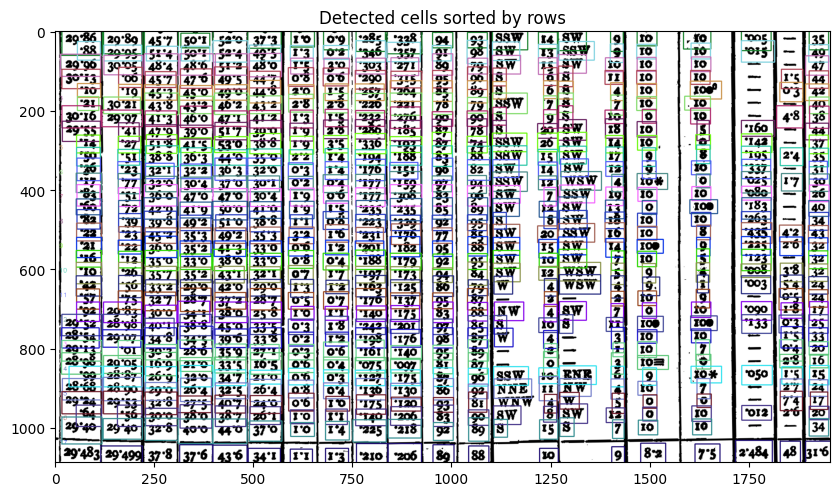

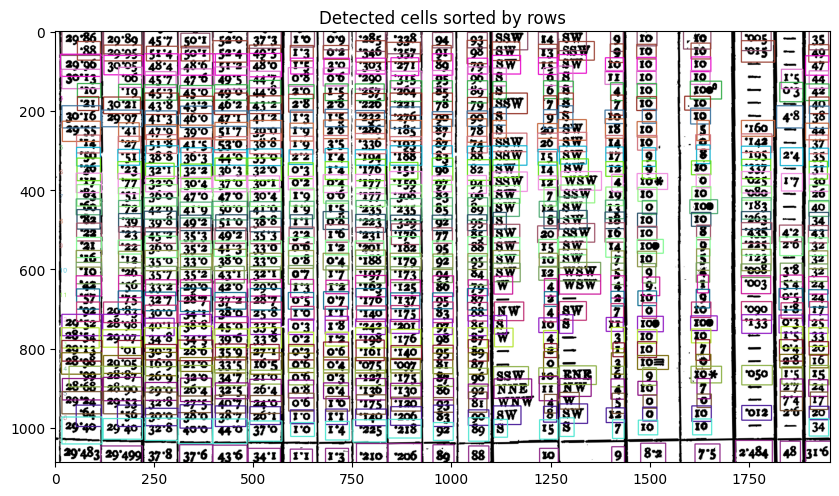

/usr/lib64/python3.9/zipfile.py:1535: UserWarning: Duplicate name: '001_1910_01_SF_B4.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib64/python3.9/zipfile.py:1535: UserWarning: Duplicate name: '001_1910_01_SF_C4.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib64/python3.9/zipfile.py:1535: UserWarning: Duplicate name: '001_1910_01_SF_D4.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib64/python3.9/zipfile.py:1535: UserWarning: Duplicate name: '001_1910_01_SF_F4.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib64/python3.9/zipfile.py:1535: UserWarning: Duplicate name: '001_1910_01_SF_K4.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib64/python3.9/zipfile.py:1535: UserWarning: Duplicate name: '001_1910_01_SF_N4.png'
  return self._open_to_write(zinfo, force_zip64=force_zip64)
/usr/lib64/python3.9/zipfile.py:1535: UserWarning: Duplicate name: '001_1910_01_SF_P4.pn

In [41]:
## Run the transcription

# All these settings below are normally already set in the config.ini file when running the full version MeteoSaver and not this Jupyter Notebook
# Set TESSDATA_PREFIX to the system's tessdata directory (for system-wide language files)
# system_tessdata_dir = 'C:/Program Files/Tesseract-OCR/tessdata'
# os.environ["TESSDATA_PREFIX"] = system_tessdata_dir
ocr_model = "Tesseract-OCR"
# ocr_model = "EasyOCR"
transient_transcription_output_dir = pre_QA_QC_transcribed_hydroclimate_data_dir_station = save_dir
station = "001" # ensure you have a folder called 807 in your transient_output_dir
month_filename = "001_1910_01_SF"
no_of_rows = 32
no_of_columns = 21 # the total columns are 30, but when i tried 30 here it wasnt arranged well because of the smaller sized columns for wind direction and strength (windrichting en kracht). I therefore tried 28, this merged someof those smaller columns. we can improve this.
no_of_rows_including_headers = 35



transcribed_table = transcription(detected_table_and_cells, ocr_model, tesseract_path, transient_transcription_output_dir, pre_QA_QC_transcribed_hydroclimate_data_dir_station, station, month_filename,
                                  no_of_rows, no_of_columns,
                                  no_of_rows_including_headers, max_cell_width_threshold, max_cell_height_threshold)


In [42]:
# Transcribed data (Not Quality Controlled)

## Note first three rows are headers and subheaders

import pandas as pd

# change this to where you saved your transcribed data (save_dir)
df = pd.read_excel(f'results/05_transient_transcription_output/001/Midpoint_Excel_with_OCR_Results.xlsx')

df

### NOTE THAT QA/QC has not yet been undertaken on the transcribed values below

,Day,Barometer \n at 32° Faht. \n at Level and \n Lattitude \n of Station,Unnamed: 2,Air Temperature.,Unnamed: 4,Unnamed: 5,Unnamed: 6,Humidity,Unnamed: 8,Unnamed: 9,...,Wind Direction\n and Force (0-12) \n or \n Velocity \n (miles per hour),Unnamed: 14,Unnamed: 15,Unnamed: 16,Cloud Amount \n and \n Weather,Unnamed: 18,Rain \n 24 \n hours \n begin- \n ning \n 9a.m,Sunshine,Min. Temp. on Grass.,Remarks
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Dep. of \n Wet.,NaN,Vapour \n Pressure.,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,9 a.m,9 p.m,9 a.m,9 p.m,Max.,Min.,9 a.m,9 p.m,9 a.m,...,9 a.m,NaN,9 p.m,NaN,9 a.m,9 p.m,NaN,NaN,NaN,NaN
2,1,2986,2989,457,60,520,393,10,9,285,...,SSW,14.0,SW,9.0,50,0,5.0,NaN,35.0,NaN
3,2,88,2995,54,50,24,495,13,2,346,...,SW,13.0,SSW,9.0,1,10,1.0,NaN,49.0,NaN
4,3,2996,3005,484,486,12,480,15,30,303,...,SW,15.0,SW,10.0,10,10,NaN,NaN,47.0,NaN
5,4,3013,06,457,476,495,447,08,06,290,...,S,6.0,E,7.0,10,10,NaN,15.0,44.0,NaN
6,5,10,19,453,45,490,448,20,15,257,...,S,6.0,S,4.0,1,3039,NaN,3.0,42.0,NaN
7,6,21,3021,433,432,462,432,28,28,226,...,SSW,7.0,S,7.0,10,10,NaN,NaN,40.0,NaN
8,7,016,2997,413,460,47,42,13,1,232,...,S,9.0,S,10.0,NaN,10,NaN,48.0,38.0,NaN
9,8,2955,41,479,390,517,390,19,28,286,...,S,2.0,SW,18.0,0,5,760.0,NaN,44.0,NaN
